# Эксперимент

## Импорт библиотек

In [17]:
%load_ext autoreload
%autoreload 2

import os
import math
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import statsmodels.api as sm

from IPython.display import display

from statsmodels.tsa.stattools import acf

from catboost import CatBoostRegressor
from statsforecast import StatsForecast
from statsforecast.models import Naive, SeasonalNaive, AutoETS, AutoTheta
from datasetsforecast.m4 import M4

import importlib

import config
import data_utils
import split_utils
import metrics_utils
import baseline_utils
import feature_configs
import feature_utils
import window_utils
import model_utils
import viz_utils

importlib.reload(config)
importlib.reload(data_utils)
importlib.reload(split_utils)
importlib.reload(metrics_utils)
importlib.reload(baseline_utils)
importlib.reload(feature_configs)
importlib.reload(feature_utils)
importlib.reload(window_utils)
importlib.reload(model_utils)
importlib.reload(viz_utils)

from config import *
from data_utils import *
from split_utils import *
from metrics_utils import *
from baseline_utils import *
from feature_configs import *
from feature_utils import *
from window_utils import *
from model_utils import *
from viz_utils import *

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (12, 5)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
SEED=42
H=12
L=36
random.seed(SEED)
np.random.seed(SEED)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 1 загрузка и фильтрация данных

In [4]:
res = prepare_filtered_sample(
    data_dir=DATA_DIR if "DATA_DIR" in globals() else "data",
    lag=12,
    alpha=0.05,
    min_len=MIN_LEN if "MIN_LEN" in globals() else 48,
    n_series=N_SERIES if "N_SERIES" in globals() else 200,
    seed=SEED,
    save=True,
    out_dir=ARTIFACTS_DIR if "ARTIFACTS_DIR" in globals() else "artifacts",
)

df = res["df"]
lengths = res["lengths"]
acf_info = res["acf_info"]
filtered_ids = res["filtered_ids"]
selected_ids = res["selected_ids"]
df_selected = res["df_selected"]
selected_info = res["selected_info"]

print("all series:", df["unique_id"].nunique())
print("after filter:", len(filtered_ids))
print("selected:", len(selected_ids))

display(selected_info.head())
display(lengths.describe())

91.7MiB [00:03, 27.2MiB/s]                           
INFO:datasetsforecast.utils:Successfully downloaded Monthly-train.csv, 91655432, bytes.
7.94MiB [00:00, 25.9MiB/s]                           
INFO:datasetsforecast.utils:Successfully downloaded Monthly-test.csv, 7942698, bytes.
4.34MiB [00:00, 16.0MiB/s]                 
INFO:datasetsforecast.utils:Successfully downloaded M4-info.csv, 4335598, bytes.
100%|██████████| 3.56M/3.56M [00:00<00:00, 5.93MiB/s]
INFO:datasetsforecast.utils:Successfully downloaded submission-Naive2.zip, 3564691, bytes.
INFO:datasetsforecast.utils:Decompressing zip file...
INFO:datasetsforecast.utils:Successfully decompressed data/m4/datasets/submission-Naive2.zip


all series: 48000
after filter: 31173
selected: 200


,unique_id,length,acf12,acf12_low,acf12_high,acf12_sig,enough_len
0,M27343,1092,0.966298,0.686289,1.246307,True,True
1,M21499,711,0.955728,0.610827,1.300630,True,True
2,M41045,577,0.952142,0.569683,1.334600,True,True
3,M25938,468,0.933221,0.512573,1.353870,True,True
4,M35540,560,0.926585,0.543189,1.309981,True,True


,length
count,48000.000000
mean,234.300229
std,137.406295
min,60.000000
25%,100.000000
50%,220.000000
75%,324.000000
max,2812.000000


ожидаемо, что у нас случайные ряды с случайными длинами, да и масштабами

ожидаемо ввиду особенностей самого датасета
Отобраны данные ежемесячных наблюдений, подходящие под критерий сезонности 

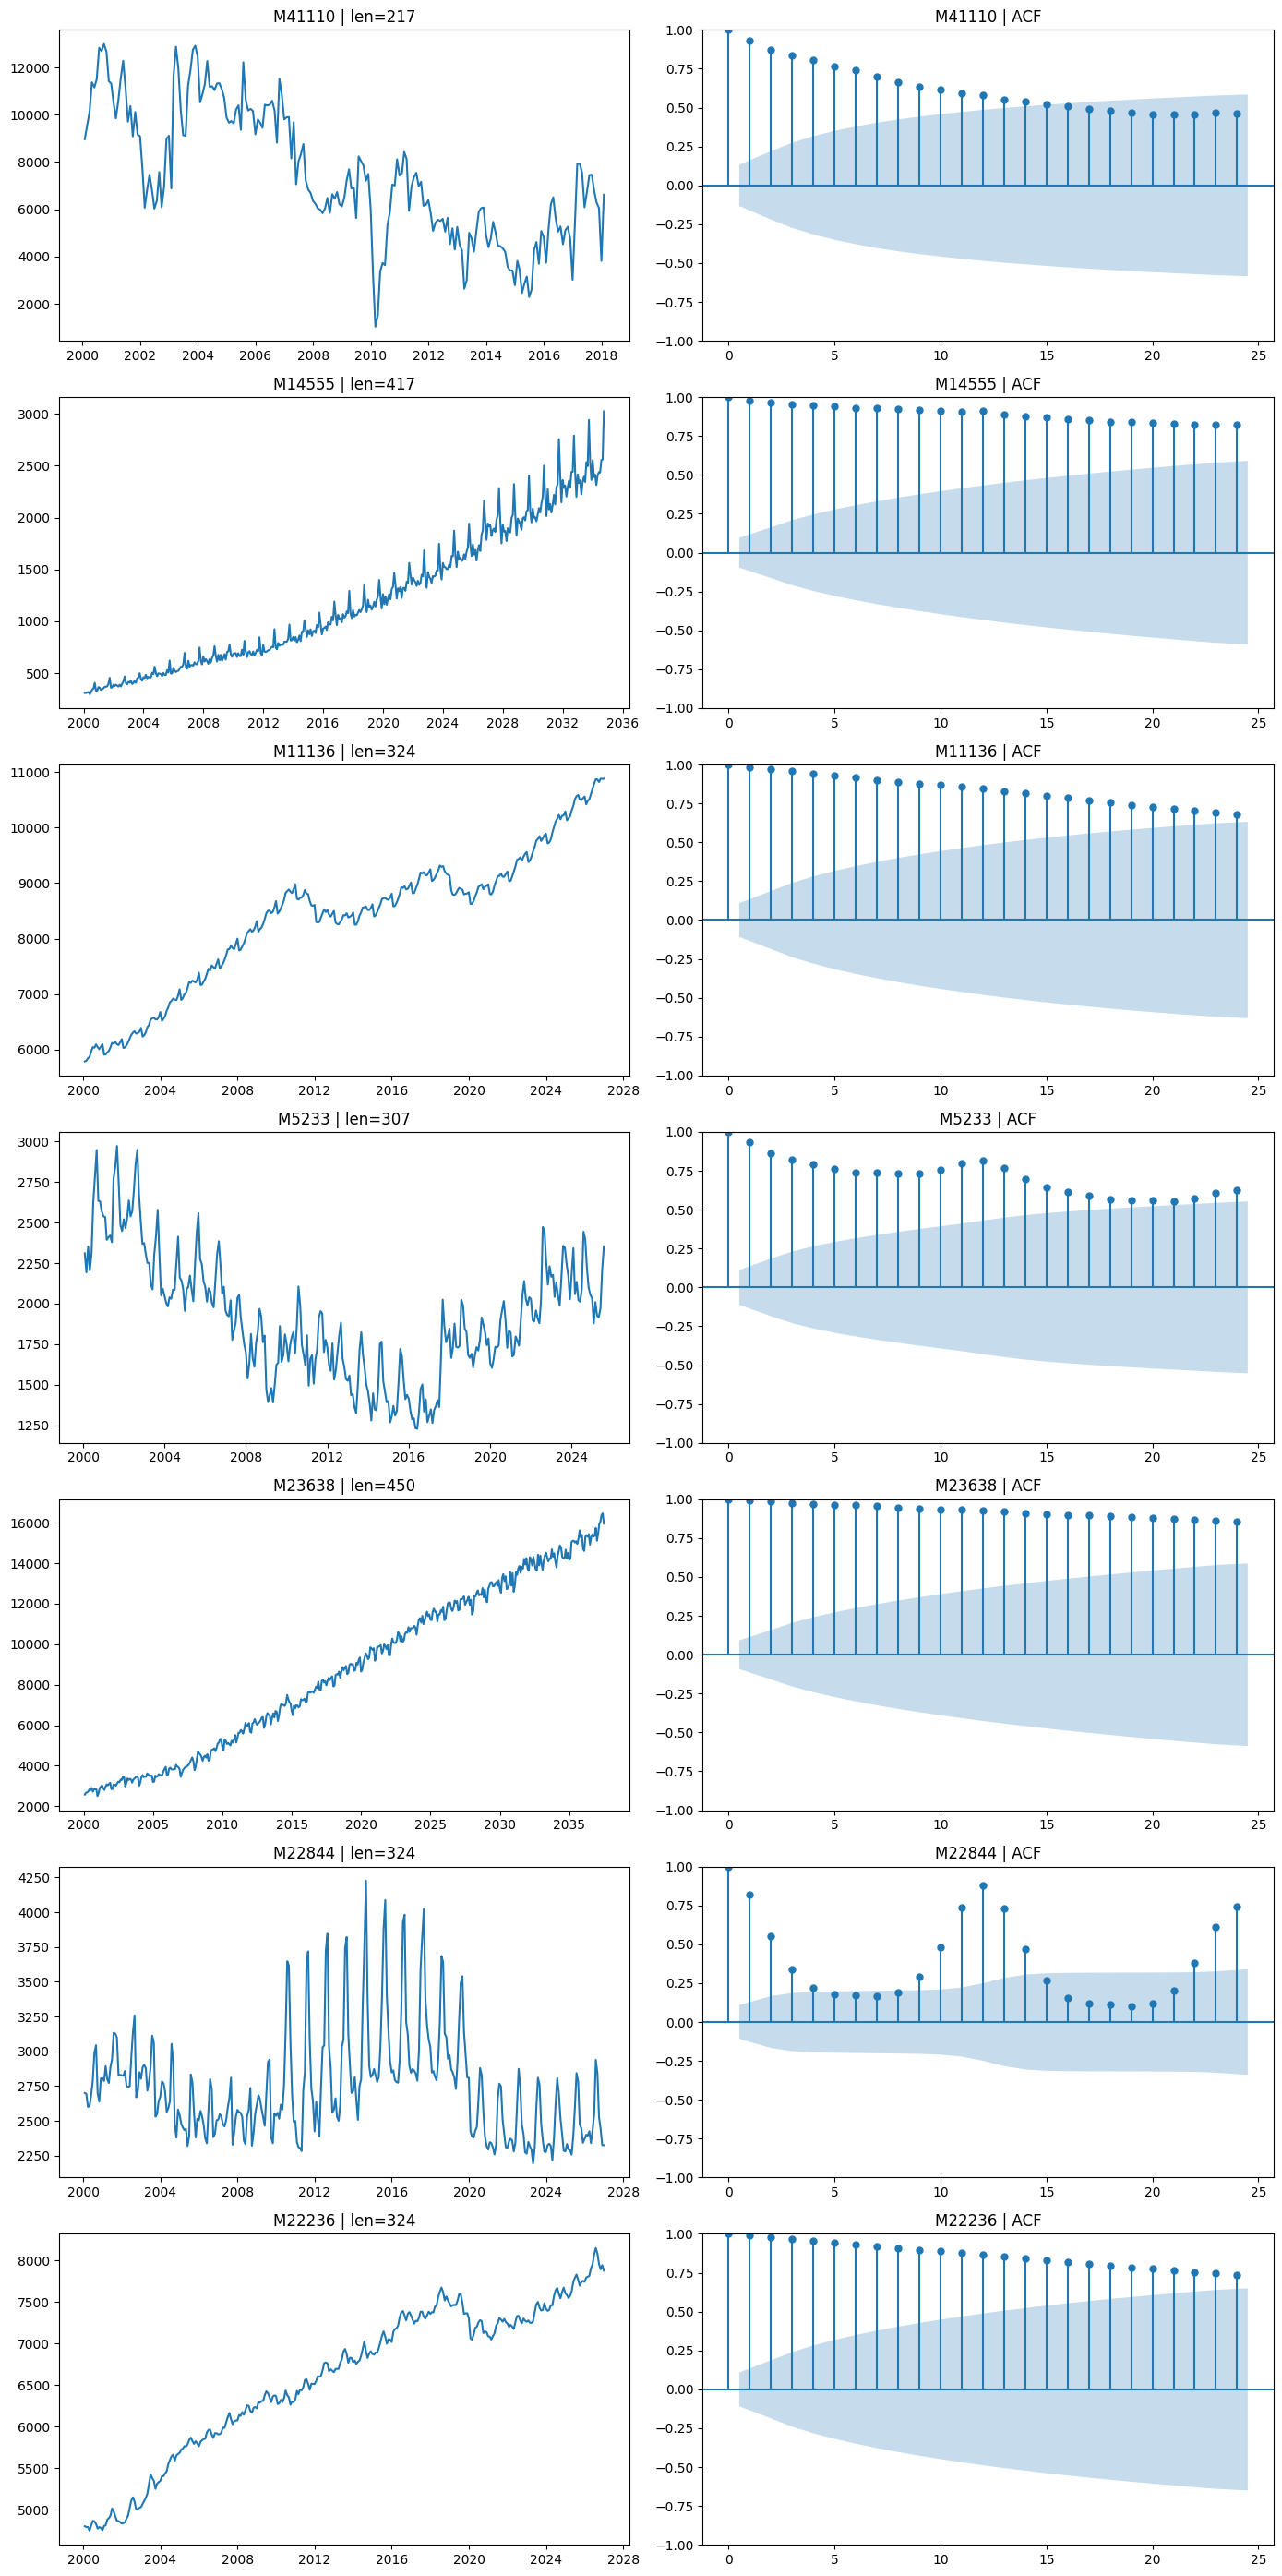

In [5]:
plot_series_acf(
    df=df_selected,
    uid=-1,
    selected_ids=selected_ids,
    n_random=7,
    seed=SEED,
    lags=24,
)

Ряды отвечают заданному критеию и видно как они фундаментально отличаются между собой при этом

In [18]:
length_check = check_series_length(
    df_selected,
    h=H,
    L=L,
)

display(length_check.head())
display(length_check.describe())

splits = make_splits_for_all_series(
    df_selected,
    h=H,
    L=L,
)

train_df = splits["train_df"]
holdout_df = splits["holdout_df"]
holdout_fit_df = splits["holdout_fit_df"]
holdout_pred_df = splits["holdout_pred_df"]
truth_df = splits["truth_df"]

sanity_check_splits(
    splits=splits,
    df=df_selected,
    h=H,
    L=L,
)

,unique_id,length,enough_for_holdout,enough_for_ml_tail
0,M10227,192,True,True
1,M10393,299,True,True
2,M10897,324,True,True
3,M1095,324,True,True
4,M1106,324,True,True


,length
count,200.000000
mean,304.680000
std,123.780961
min,97.000000
25%,220.000000
50%,317.500000
75%,324.000000
max,1092.000000


splits look ok


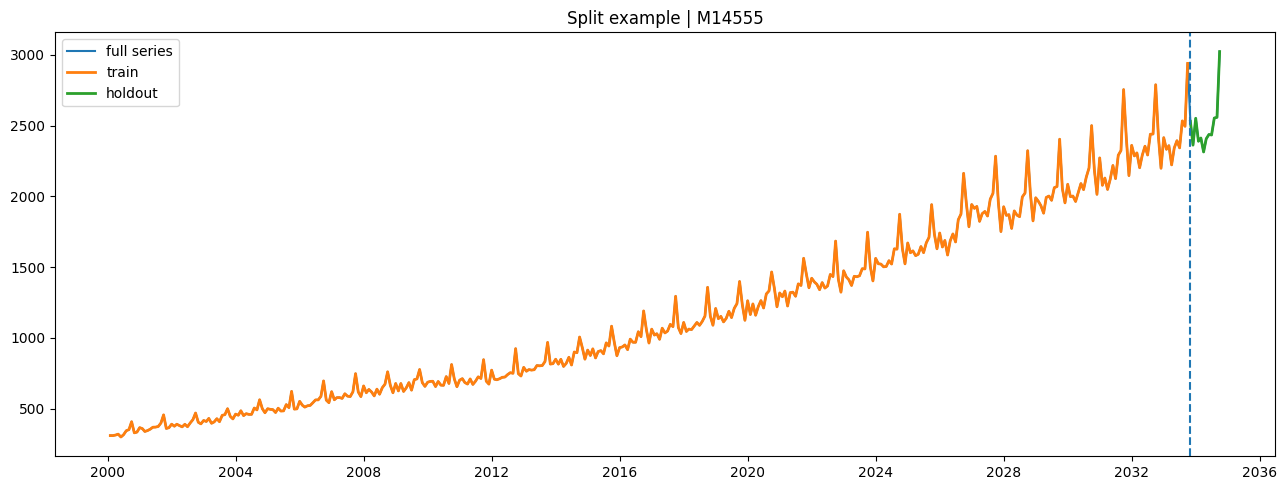

In [20]:
uid_example = random.choice(selected_ids)

g = df_selected[df_selected["unique_id"] == uid_example].sort_values("ds").copy()
parts = split_one_series(g, h=12, L=36)

plt.figure(figsize=(13, 5))
plt.plot(g["ds"], g["y"], label="full series")
plt.plot(parts["train_block"]["ds"], parts["train_block"]["y"], label="train", linewidth=2)
plt.plot(parts["holdout_block"]["ds"], parts["holdout_block"]["y"], label="holdout", linewidth=2)
plt.axvline(parts["holdout_block"]["ds"].iloc[0], linestyle="--")
plt.title(f"Split example | {uid_example}")
plt.legend()
plt.tight_layout()
plt.show()

## Построение бейзлайнов

первые M-h наблюдений образуют обучающую часть ряда, а последние h наблюдений финальный holdout-горизонт, на котором оценивается качество прогноза. Для бейзлайнов этого достаточни,  они будут обучаться на первых M-h точках и построят прогноз на последние h точек

h=12

In [21]:
baseline_res = run_all_baselines(
    train_df=train_df,
    h=12,
    season_length=12,
    freq="M",
)

forecasts_df = baseline_res["forecasts_df"]
baseline_pred_dict = baseline_res["pred_dict"]

sanity_check_baseline_forecasts(
    forecasts_df=forecasts_df,
    h=12,
    n_ids_expected=train_df["unique_id"].nunique(),
)

display(forecasts_df.head())
print(forecasts_df.columns.tolist())

baseline forecasts look ok


,unique_id,ds,Naive,SeasonalNaive,AutoETS,AutoTheta
0,M10227,2015-01-31,2730.0,4240.0,4547.166544,4310.382884
1,M10227,2015-02-28,2730.0,6510.0,5600.441798,5027.897835
2,M10227,2015-03-31,2730.0,2360.0,2695.835076,2664.423026
3,M10227,2015-04-30,2730.0,3010.0,2466.646335,2403.449896
4,M10227,2015-05-31,2730.0,2770.0,2580.800539,2540.647052


['unique_id', 'ds', 'Naive', 'SeasonalNaive', 'AutoETS', 'AutoTheta']


In [22]:
baseline_metrics = {}

for model_name, pred_df in baseline_pred_dict.items():
    baseline_metrics[model_name] = evaluate_one_model_per_series(
        train_df=train_df,
        truth_df=truth_df,
        pred_df=pred_df,
        m=12,
    )

baseline_summary = compare_models(baseline_metrics)
baseline_wins_mase = count_series_wins(baseline_metrics, metric="mase")
baseline_wins_smape = count_series_wins(baseline_metrics, metric="smape")

display(baseline_summary)
display(baseline_wins_mase)
display(baseline_wins_smape)

,model,mean_smape,median_smape,mean_mase,median_mase,n_series
0,AutoETS,6.458918,3.122006,0.754907,0.621262,200
1,AutoTheta,6.323814,2.936599,0.762348,0.616357,200
2,SeasonalNaive,7.643086,3.975576,0.999942,0.819032,200
3,Naive,8.499195,3.805800,1.155148,0.792667,200


,model,n_wins,share_wins
0,AutoTheta,64,0.320
1,AutoETS,61,0.305
2,Naive,46,0.230
3,SeasonalNaive,29,0.145


,model,n_wins,share_wins
0,AutoTheta,64,0.320
1,AutoETS,59,0.295
2,Naive,45,0.225
3,SeasonalNaive,32,0.160


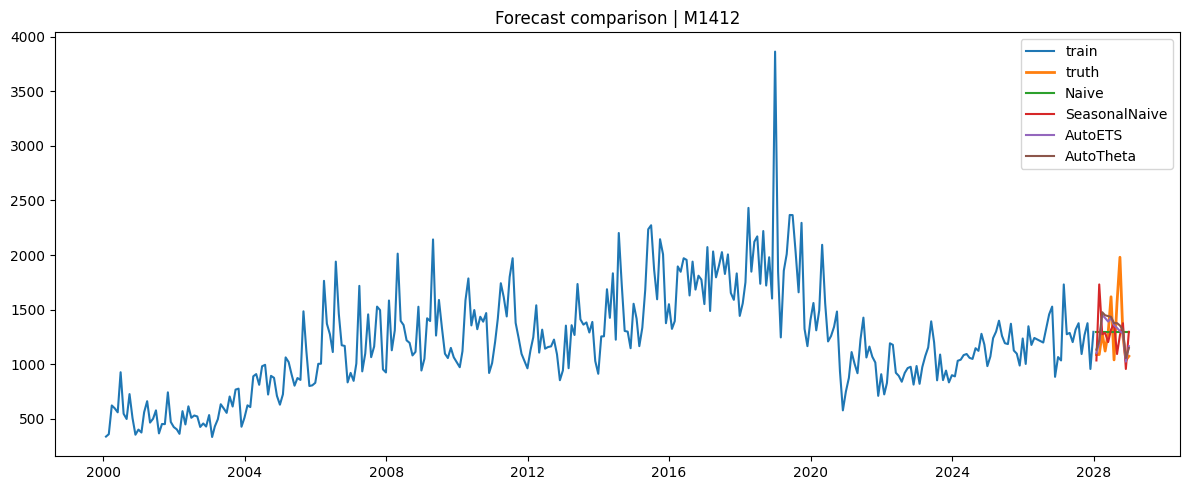

In [30]:
uid_example = random.choice(selected_ids)

plot_forecast_comparison(
    train_df=train_df,
    truth_df=truth_df,
    pred_dict=baseline_pred_dict,
    uid=uid_example,
)

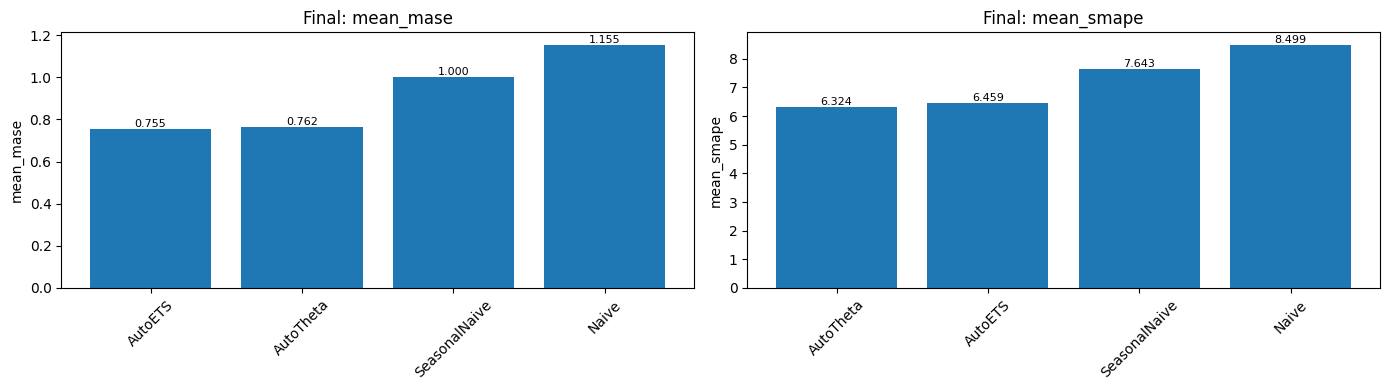

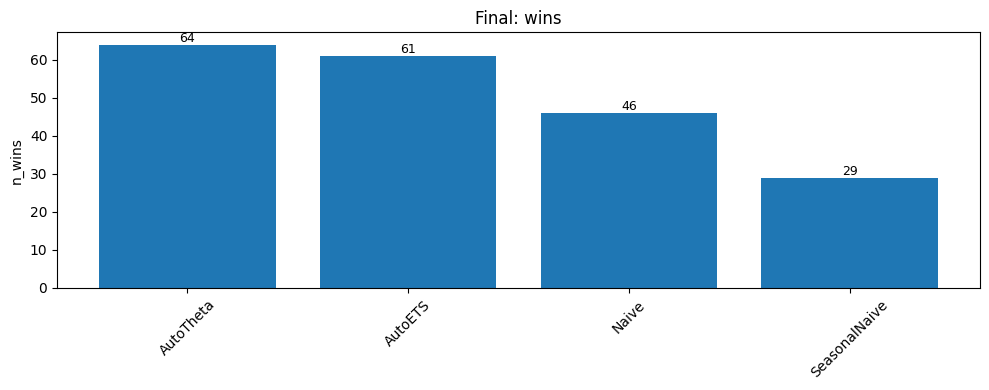

In [31]:
plot_final_comparison(
    summary_df=baseline_summary,
    wins_df=baseline_wins_mase,
    model_col="model",
    metric_1="mean_mase",
    metric_2="mean_smape",
)

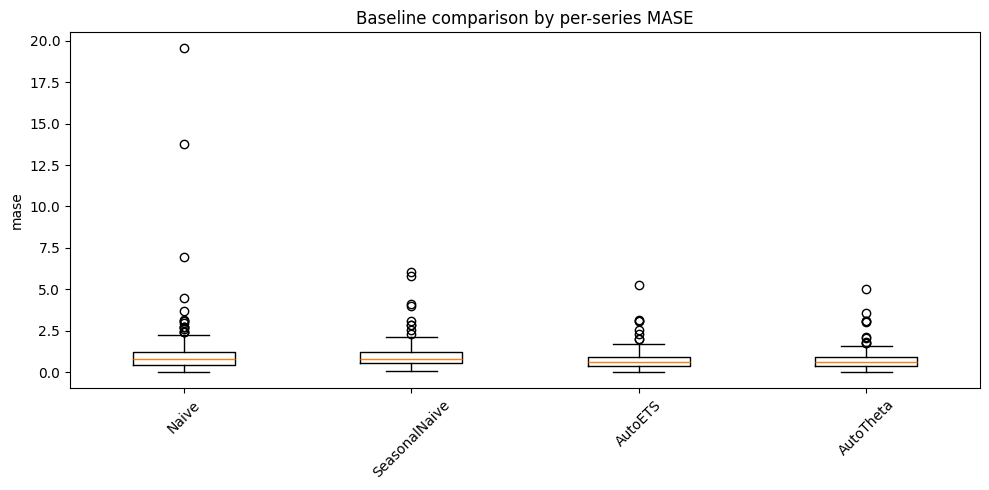

In [32]:
plot_metric_boxplot(
    metrics_dict=baseline_metrics,
    metric="mase",
    title="Baseline comparison by per-series MASE",
)

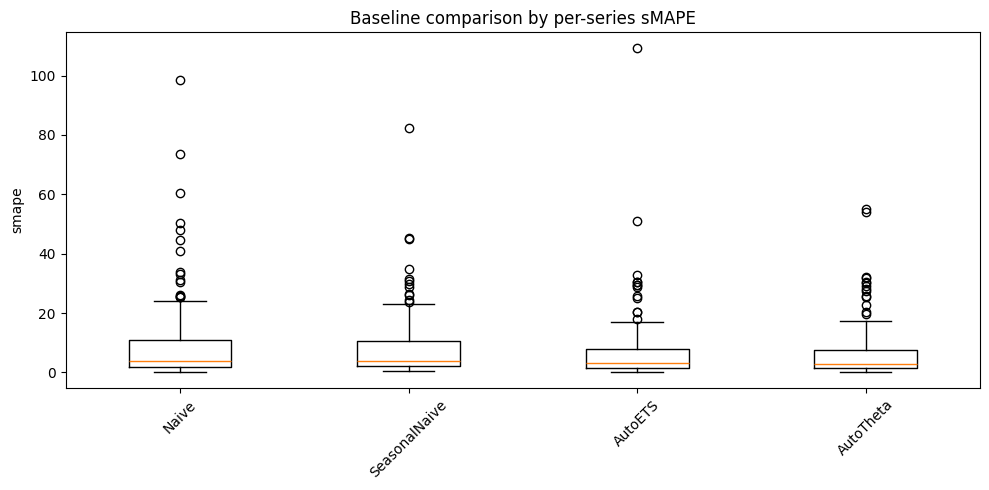

In [33]:
plot_metric_boxplot(
    metrics_dict=baseline_metrics,
    metric="smape",
    title="Baseline comparison by per-series sMAPE",
)

Бейзлайны показали ожидаемый результат - лучшими оказались AutoETS и AutoTheta

По mean_mase немного лучше выглядит AutoETS, по mean_smape и числу побед на отдельных рядах небольшое преимущество у AutoTheta. Наивные модели заметно слабее, в дальнейшем будем сравнивать с этими двумя бейзлайнами

## Шаг 1 - оценка разных вариантов признаков сезонности при фиксированных параметрах горизонта модели и истории 

In [34]:
stage1_history = 36
stage1_model_horizon = 4

stage1_configs = get_all_feature_configs()
[cfg["name"] for cfg in stage1_configs]

['lags_only',
 'lags_seasonal',
 'lags_calendar',
 'lags_fourier',
 'lags_seasonal_calendar',
 'lags_seasonal_fourier']

In [35]:
stage1_results = {}
stage1_metrics = {}
stage1_summary_parts = []

catboost_params_stage1 = {
    "loss_function": "RMSE",
    "iterations": 200,
    "depth": 6,
    "learning_rate": 0.05,
    "verbose": False,
    "random_seed": SEED,
}

In [37]:
for cfg in stage1_configs:
    cfg_name = cfg["name"]
    print(f"running: {cfg_name}")

    ml_res = run_catboost_pipeline(
        train_df=train_df,
        holdout_df=holdout_fit_df,
        truth_df=truth_df,
        config=cfg,
        history=stage1_history,
        h=12,
        model_horizon=stage1_model_horizon,
        catboost_params=catboost_params_stage1,
    )

    pred_df_ml = ml_res["pred_df"]

    ml_metrics = evaluate_one_model_per_series(
        train_df=train_df,
        truth_df=truth_df,
        pred_df=pred_df_ml,
        m=12,
    )

    one_summary = summarize_metrics(
        ml_metrics,
        model_name=cfg_name,
    )

    stage1_results[cfg_name] = ml_res
    stage1_metrics[cfg_name] = ml_metrics
    stage1_summary_parts.append(one_summary)

running: lags_only
running: lags_seasonal
running: lags_calendar
running: lags_fourier
running: lags_seasonal_calendar
running: lags_seasonal_fourier


In [38]:
stage1_summary = (
    pd.concat(stage1_summary_parts, axis=0)
    .reset_index(drop=True)
    .sort_values(["mean_mase", "mean_smape"])
    .reset_index(drop=True)
)

stage1_wins_mase = count_series_wins(stage1_metrics, metric="mase")
stage1_wins_smape = count_series_wins(stage1_metrics, metric="smape")

display(stage1_summary)
display(stage1_wins_mase)
display(stage1_wins_smape)

,mean_smape,median_smape,mean_mase,median_mase,n_series,model
0,8.144990,4.022777,1.088959,0.803836,200,lags_seasonal_fourier
1,8.216628,4.163428,1.098513,0.810589,200,lags_seasonal
2,8.221393,4.039148,1.099901,0.835900,200,lags_seasonal_calendar
3,8.169273,4.061358,1.114789,0.806314,200,lags_fourier
4,8.245062,4.345446,1.129180,0.842911,200,lags_only
5,8.283831,4.395723,1.152144,0.827963,200,lags_calendar


,model,n_wins,share_wins
0,lags_fourier,42,0.210
1,lags_seasonal_calendar,36,0.180
2,lags_seasonal_fourier,36,0.180
3,lags_seasonal,31,0.155
4,lags_only,29,0.145
5,lags_calendar,26,0.130


,model,n_wins,share_wins
0,lags_fourier,42,0.210
1,lags_seasonal_calendar,35,0.175
2,lags_seasonal_fourier,35,0.175
3,lags_seasonal,31,0.155
4,lags_only,29,0.145
5,lags_calendar,28,0.140


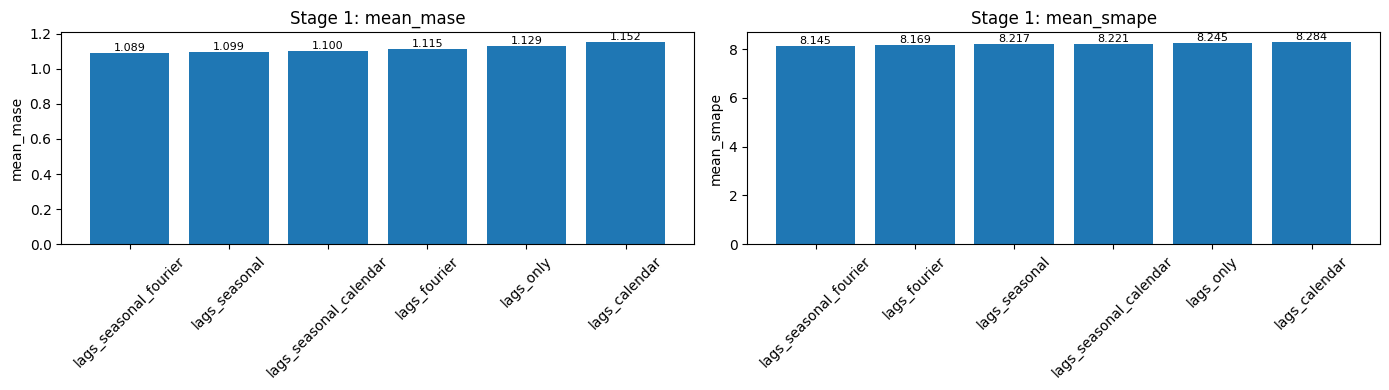

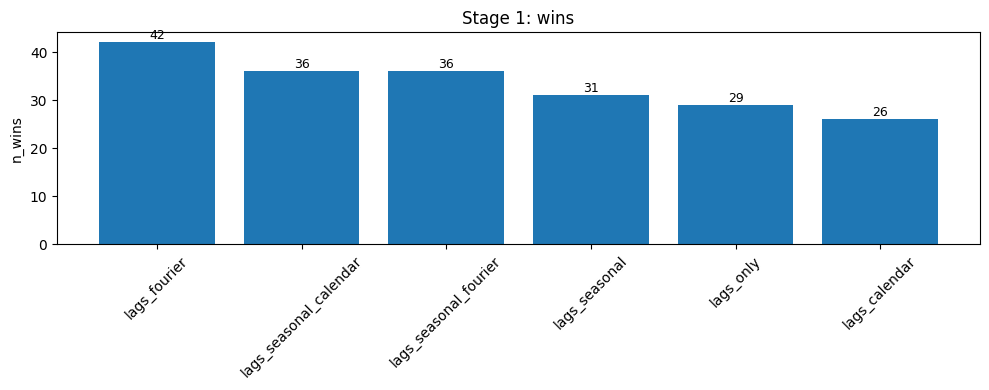

In [39]:
plot_stage1_summary(
    summary_df=stage1_summary,
    wins_df=stage1_wins_mase,
    model_col="model",
    metric_1="mean_mase",
    metric_2="mean_smape",
)

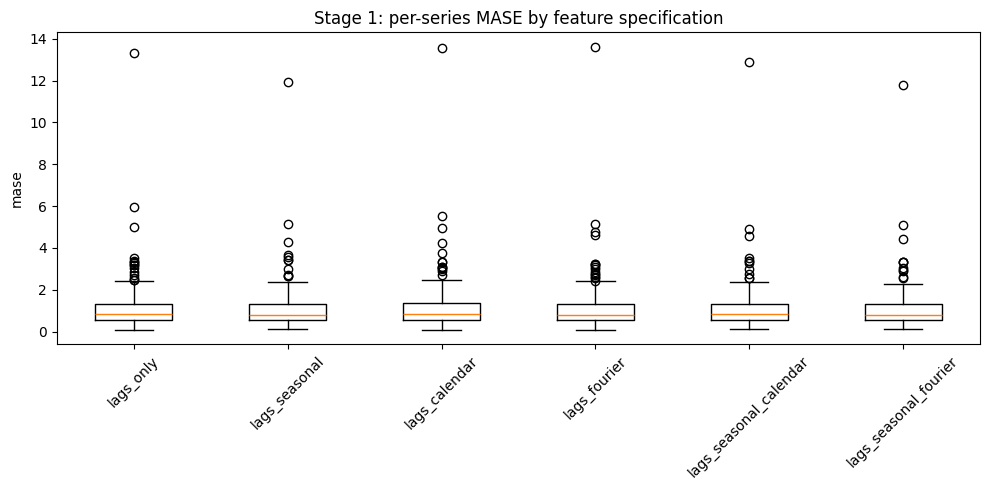

In [40]:
plot_metric_boxplot(
    metrics_dict=stage1_metrics,
    metric="mase",
    title="Stage 1: per-series MASE by feature specification",
)

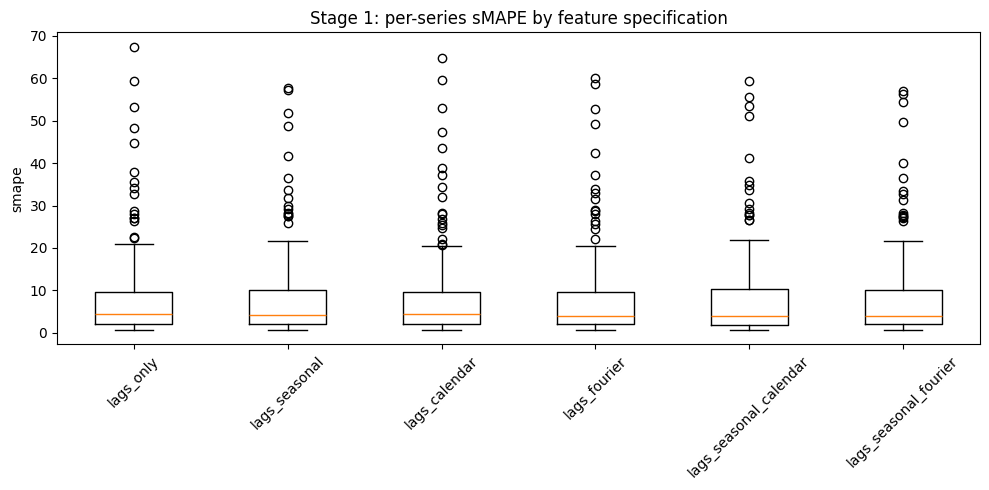

In [41]:
plot_metric_boxplot(
    metrics_dict=stage1_metrics,
    metric="smape",
    title="Stage 1: per-series sMAPE by feature specification",
)

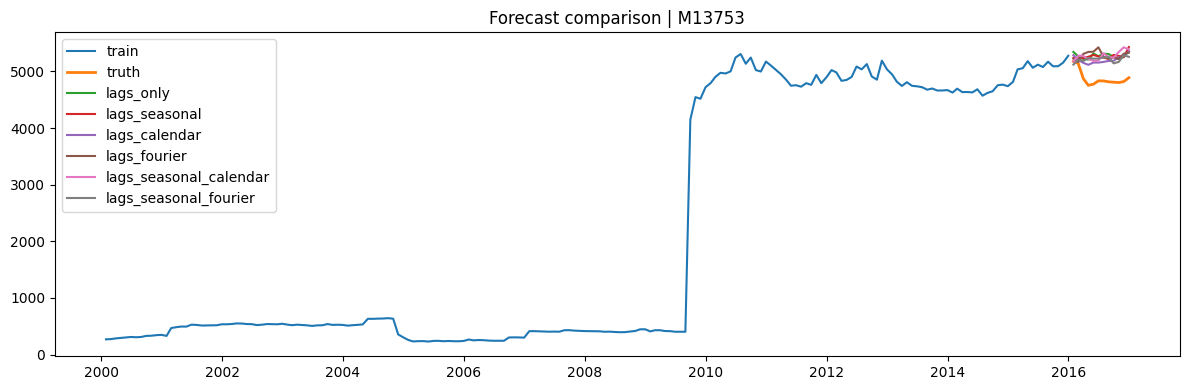

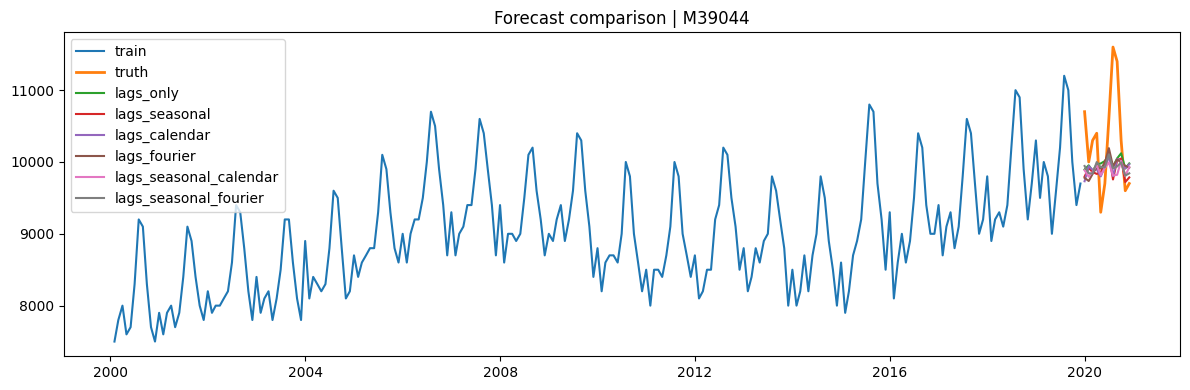

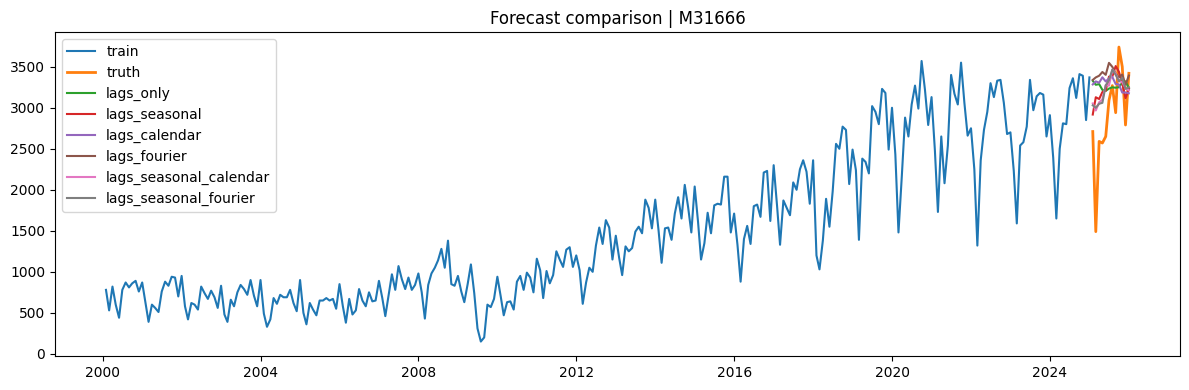

In [43]:
stage1_pred_dict = {
    cfg_name: stage1_results[cfg_name]["pred_df"]
    for cfg_name in stage1_results
}
uids_example = random.sample(selected_ids, 3)

plot_forecast_comparison_many(
    train_df=train_df,
    truth_df=truth_df,
    pred_dict=stage1_pred_dict,
    uids=uids_example,
)

Если ориентироваться на основные метрики качества, то лучшей спецификацией на первом этапе оказался вариант lags_seasonal_fourier. Он показал минимальные средние значения как MASE, так и sMAPE. Очень близко к нему расположились lags_seasonal и lags_seasonal_calendar, тогда как lags_only и особенно lags_calendar выглядели слабее.

Если смотреть на число рядов, на которых спецификация оказалась лучшей, первое место занял вариант lags_fourier. Однако этот показатель является скорее вспомогательным, он отражает, как часто модель выигрывает на отдельных рядах, но не показывает, насколько велико это преимущество и насколько стабильна ошибка в среднем по выборке.

В целом – явное кодирование сезонности действительно улучшает качество прогноза. Если выбирать только один способ задания сезонности, то наилучшим вариантом выглядят Fourier-признаки. При этом максимальное среднее качество достигается уже не при одной кодировке, а при совместном использовании нескольких способов задания сезонности, то есть в комбинации обычных лагов, сезонных лагов и Fourier-признаков.


## промежуточные мысли между шагом 1 и шагом 2

Результат первого этапа пока нельзя считать универсальным, поскольку сравнение проводилось только при одной фиксированной комбинации history и model_horizon. Поэтому на втором этапе важно проверить, сохраняется ли выявленный эффект при изменении параметров forecasting pipeline, или предпочтительная кодировка сезонности меняется вместе с настройками модели.

Кроме того, полученный результат в определенной степени ожидаем: в исследование изначально были отобраны ряды с выраженной сезонностью по критерию ACF(12), поэтому спецификации с явным учетом сезонной структуры уже на первом этапе должны были получить преимущество.

## Шаг 2 -  анализ чувствительности к выбранному горизонту и истории для каждой из спецификаций

In [54]:
stage2_history_grid = [24, 36, 48]
stage2_model_horizon_grid = [1, 4, 6]

catboost_params_stage2 = {
    "loss_function": "RMSE",
    "iterations": 200,
    "depth": 6,
    "learning_rate": 0.05,
    "verbose": False,
    "random_seed": SEED,
}

In [55]:
def make_custom_holdout_tail(
    df,
    tail_len,
    id_col="unique_id",
    date_col="ds",
):
    parts = []

    for _, g in df.groupby(id_col):
        g = g.sort_values(date_col).reset_index(drop=True).copy()

        if len(g) < tail_len:
            raise ValueError(
                f"Ряд {g[id_col].iloc[0]} слишком короткий для tail_len={tail_len}"
            )

        parts.append(g.iloc[-tail_len:].copy())

    out = pd.concat(parts, axis=0).reset_index(drop=True)
    return out

In [56]:
stage2_tail_len = max(stage2_history_grid) + 12
print("stage2_tail_len =", stage2_tail_len)

holdout_fit_stage2_df = make_custom_holdout_tail(
    df=df_selected,
    tail_len=stage2_tail_len,
)

print(holdout_fit_stage2_df.groupby("unique_id").size().head())

stage2_tail_len = 60
unique_id
M10227    60
M10393    60
M10897    60
M1095     60
M1106     60
dtype: int64


In [57]:
def run_stage2_for_one_config(
    config_name,
    train_df,
    holdout_fit_df,
    truth_df,
    history_grid,
    model_horizon_grid,
    h=12,
    m=12,
    catboost_params=None,
):
    cfg = get_feature_config_by_name(config_name)

    rows = []
    metrics_store = {}

    for history in history_grid:
        for model_horizon in model_horizon_grid:
            print(f"{config_name} | history={history} | model_horizon={model_horizon}")

            ml_res = run_catboost_pipeline(
                train_df=train_df,
                holdout_df=holdout_fit_df,
                truth_df=truth_df,
                config=cfg,
                history=history,
                h=h,
                model_horizon=model_horizon,
                catboost_params=catboost_params,
            )

            pred_df_ml = ml_res["pred_df"]

            ml_metrics = evaluate_one_model_per_series(
                train_df=train_df,
                truth_df=truth_df,
                pred_df=pred_df_ml,
                m=m,
            )

            one_summary = summarize_metrics(
                ml_metrics,
                model_name=config_name,
            ).iloc[0].to_dict()

            one_summary["config_name"] = config_name
            one_summary["history"] = history
            one_summary["model_horizon"] = model_horizon

            rows.append(one_summary)
            metrics_store[(history, model_horizon)] = {
                "pred_df": pred_df_ml,
                "metrics_df": ml_metrics,
                "ml_res": ml_res,
            }

    grid_df = (
        pd.DataFrame(rows)
        .sort_values(["history", "model_horizon"])
        .reset_index(drop=True)
    )

    return grid_df, metrics_store

### запуск для lags_only

In [58]:
grid_lags_only, metrics_lags_only = run_stage2_for_one_config(
    config_name="lags_only",
    train_df=train_df,
    holdout_fit_df=holdout_fit_stage2_df,
    truth_df=truth_df,
    history_grid=stage2_history_grid,
    model_horizon_grid=stage2_model_horizon_grid,
    h=12,
    m=12,
    catboost_params=catboost_params_stage2,
)

display(grid_lags_only)

lags_only | history=24 | model_horizon=1
lags_only | history=24 | model_horizon=4
lags_only | history=24 | model_horizon=6
lags_only | history=36 | model_horizon=1
lags_only | history=36 | model_horizon=4
lags_only | history=36 | model_horizon=6
lags_only | history=48 | model_horizon=1
lags_only | history=48 | model_horizon=4
lags_only | history=48 | model_horizon=6


,mean_smape,median_smape,mean_mase,median_mase,n_series,model,config_name,history,model_horizon
0,13.365743,6.383069,1.835379,1.428148,200,lags_only,lags_only,24,1
1,13.357543,6.506907,1.832439,1.421904,200,lags_only,lags_only,24,4
2,13.342696,6.230557,1.833094,1.413763,200,lags_only,lags_only,24,6
3,10.454739,5.183489,1.463458,1.064999,200,lags_only,lags_only,36,1
4,10.448884,5.092275,1.449110,1.036166,200,lags_only,lags_only,36,4
5,10.484368,5.219525,1.460167,1.094653,200,lags_only,lags_only,36,6
6,8.267522,4.293626,1.128975,0.834144,200,lags_only,lags_only,48,1
7,8.290170,4.301818,1.138227,0.849823,200,lags_only,lags_only,48,4
8,8.296557,4.048293,1.131524,0.832317,200,lags_only,lags_only,48,6


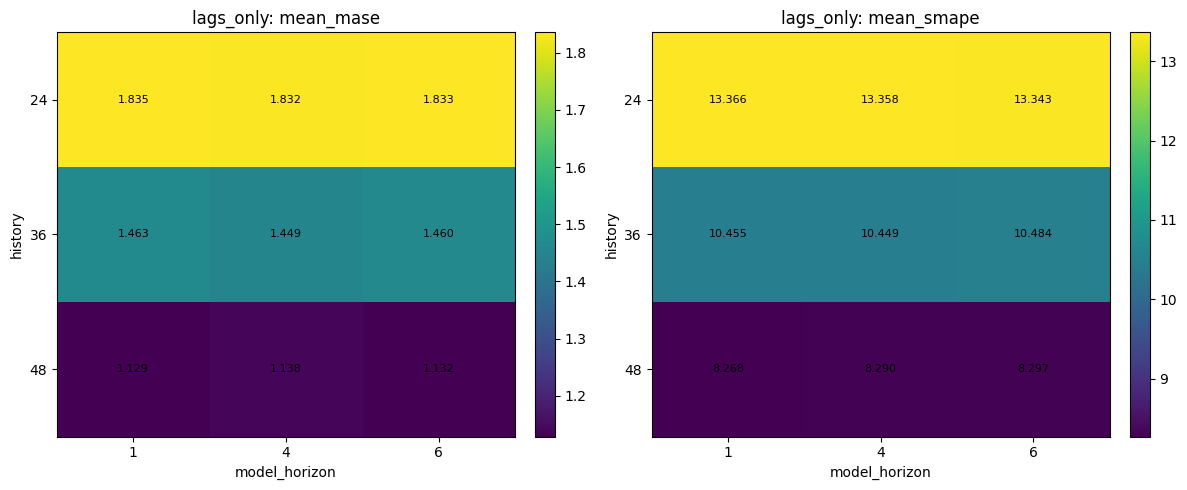

In [59]:
plot_two_heatmaps(
    df=grid_lags_only,
    value_col_1="mean_mase",
    value_col_2="mean_smape",
    index_col="history",
    columns_col="model_horizon",
    title_1="lags_only: mean_mase",
    title_2="lags_only: mean_smape",
)

In [60]:
display(grid_lags_only.sort_values("mean_mase").head(3))
display(grid_lags_only.sort_values("mean_smape").head(3))

,mean_smape,median_smape,mean_mase,median_mase,n_series,model,config_name,history,model_horizon
6,8.267522,4.293626,1.128975,0.834144,200,lags_only,lags_only,48,1
8,8.296557,4.048293,1.131524,0.832317,200,lags_only,lags_only,48,6
7,8.290170,4.301818,1.138227,0.849823,200,lags_only,lags_only,48,4


,mean_smape,median_smape,mean_mase,median_mase,n_series,model,config_name,history,model_horizon
6,8.267522,4.293626,1.128975,0.834144,200,lags_only,lags_only,48,1
7,8.290170,4.301818,1.138227,0.849823,200,lags_only,lags_only,48,4
8,8.296557,4.048293,1.131524,0.832317,200,lags_only,lags_only,48,6


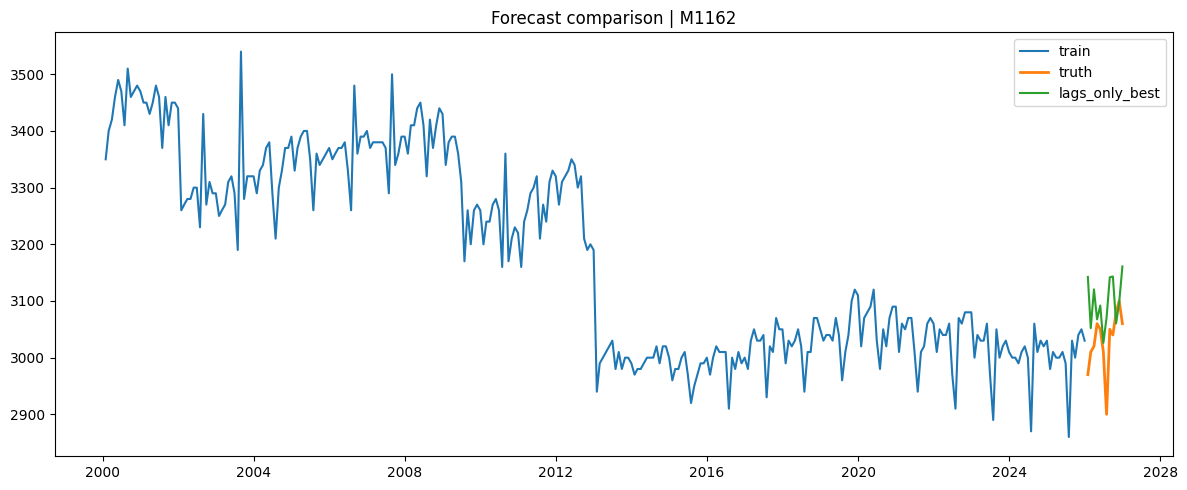

In [61]:
best_lags_only = grid_lags_only.sort_values("mean_mase").iloc[0]
best_history_lags_only = int(best_lags_only["history"])
best_model_horizon_lags_only = int(best_lags_only["model_horizon"])

best_pred_lags_only = metrics_lags_only[(best_history_lags_only, best_model_horizon_lags_only)]["pred_df"]

uid_example = random.choice(selected_ids)

plot_forecast_comparison(
    train_df=train_df,
    truth_df=truth_df,
    pred_dict={"lags_only_best": best_pred_lags_only},
    uid=uid_example,
)

Для lags_only основной эффект дает увеличение history -ее увеличение улучшает метрики 
Влияние model_horizon внутри этой спецификации почти нет, лучший результат достигается при history=48 и model_horizon=1

### запуск для lags_seasonal

In [62]:
grid_lags_seasonal, metrics_lags_seasonal = run_stage2_for_one_config(
    config_name="lags_seasonal",
    train_df=train_df,
    holdout_fit_df=holdout_fit_stage2_df,
    truth_df=truth_df,
    history_grid=stage2_history_grid,
    model_horizon_grid=stage2_model_horizon_grid,
    h=12,
    m=12,
    catboost_params=catboost_params_stage2,
)

display(grid_lags_seasonal)

lags_seasonal | history=24 | model_horizon=1
lags_seasonal | history=24 | model_horizon=4
lags_seasonal | history=24 | model_horizon=6
lags_seasonal | history=36 | model_horizon=1
lags_seasonal | history=36 | model_horizon=4
lags_seasonal | history=36 | model_horizon=6
lags_seasonal | history=48 | model_horizon=1
lags_seasonal | history=48 | model_horizon=4
lags_seasonal | history=48 | model_horizon=6


,mean_smape,median_smape,mean_mase,median_mase,n_series,model,config_name,history,model_horizon
0,13.482121,6.691421,1.857020,1.457186,200,lags_seasonal,lags_seasonal,24,1
1,13.510916,6.934529,1.870036,1.419800,200,lags_seasonal,lags_seasonal,24,4
2,13.528379,6.704136,1.862384,1.388350,200,lags_seasonal,lags_seasonal,24,6
3,10.598843,5.425141,1.463569,1.076181,200,lags_seasonal,lags_seasonal,36,1
4,10.664119,5.578990,1.472472,1.103372,200,lags_seasonal,lags_seasonal,36,4
5,10.674302,5.512091,1.467401,1.100208,200,lags_seasonal,lags_seasonal,36,6
6,8.156302,3.996021,1.078867,0.783107,200,lags_seasonal,lags_seasonal,48,1
7,8.171228,4.020628,1.085531,0.777961,200,lags_seasonal,lags_seasonal,48,4
8,8.190928,4.029077,1.083757,0.802590,200,lags_seasonal,lags_seasonal,48,6


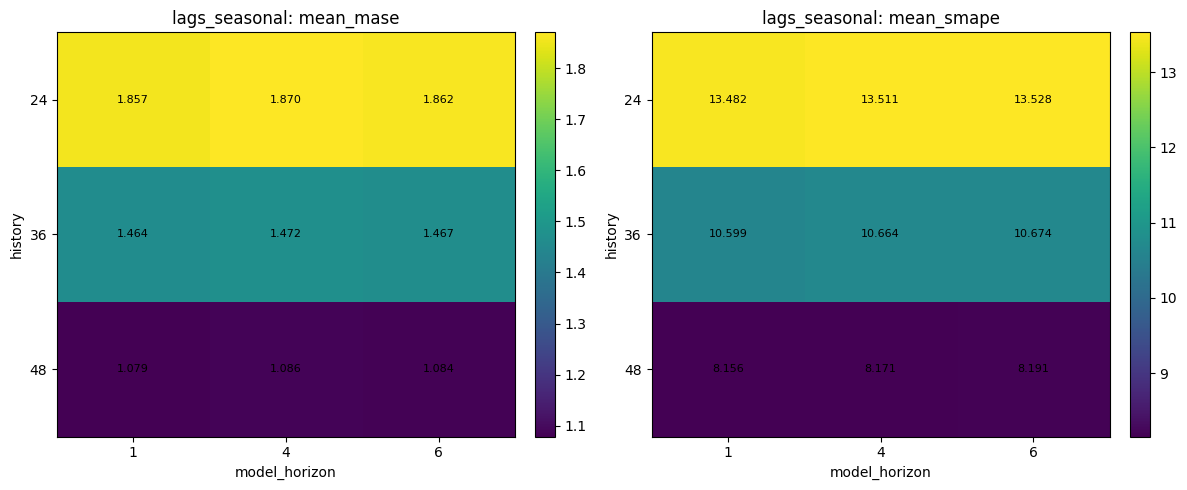

In [63]:
plot_two_heatmaps(
    df=grid_lags_seasonal,
    value_col_1="mean_mase",
    value_col_2="mean_smape",
    index_col="history",
    columns_col="model_horizon",
    title_1="lags_seasonal: mean_mase",
    title_2="lags_seasonal: mean_smape",
)

In [64]:
display(grid_lags_seasonal.sort_values("mean_mase").head(3))
display(grid_lags_seasonal.sort_values("mean_smape").head(3))

,mean_smape,median_smape,mean_mase,median_mase,n_series,model,config_name,history,model_horizon
6,8.156302,3.996021,1.078867,0.783107,200,lags_seasonal,lags_seasonal,48,1
8,8.190928,4.029077,1.083757,0.802590,200,lags_seasonal,lags_seasonal,48,6
7,8.171228,4.020628,1.085531,0.777961,200,lags_seasonal,lags_seasonal,48,4


,mean_smape,median_smape,mean_mase,median_mase,n_series,model,config_name,history,model_horizon
6,8.156302,3.996021,1.078867,0.783107,200,lags_seasonal,lags_seasonal,48,1
7,8.171228,4.020628,1.085531,0.777961,200,lags_seasonal,lags_seasonal,48,4
8,8.190928,4.029077,1.083757,0.802590,200,lags_seasonal,lags_seasonal,48,6


метрики лучше, эффект такой же как в предыдущем шаге -увеличение history имеет значение влияние model_horizon минорно 

### запуск для lags_calendar

In [65]:
grid_lags_calendar, metrics_lags_calendar = run_stage2_for_one_config(
    config_name="lags_calendar",
    train_df=train_df,
    holdout_fit_df=holdout_fit_stage2_df,
    truth_df=truth_df,
    history_grid=stage2_history_grid,
    model_horizon_grid=stage2_model_horizon_grid,
    h=12,
    m=12,
    catboost_params=catboost_params_stage2,
)

display(grid_lags_calendar)

lags_calendar | history=24 | model_horizon=1
lags_calendar | history=24 | model_horizon=4
lags_calendar | history=24 | model_horizon=6
lags_calendar | history=36 | model_horizon=1
lags_calendar | history=36 | model_horizon=4
lags_calendar | history=36 | model_horizon=6
lags_calendar | history=48 | model_horizon=1
lags_calendar | history=48 | model_horizon=4
lags_calendar | history=48 | model_horizon=6


,mean_smape,median_smape,mean_mase,median_mase,n_series,model,config_name,history,model_horizon
0,13.449731,6.996550,1.849816,1.395340,200,lags_calendar,lags_calendar,24,1
1,13.386255,6.877896,1.845856,1.461343,200,lags_calendar,lags_calendar,24,4
2,13.457162,6.763412,1.840333,1.410137,200,lags_calendar,lags_calendar,24,6
3,10.484499,5.072315,1.439029,1.090708,200,lags_calendar,lags_calendar,36,1
4,10.523320,4.886482,1.470791,1.064765,200,lags_calendar,lags_calendar,36,4
5,10.520602,5.113772,1.461582,1.079904,200,lags_calendar,lags_calendar,36,6
6,8.234182,3.900225,1.117268,0.822950,200,lags_calendar,lags_calendar,48,1
7,8.273970,4.314320,1.138348,0.798167,200,lags_calendar,lags_calendar,48,4
8,8.252151,4.070135,1.137702,0.843906,200,lags_calendar,lags_calendar,48,6


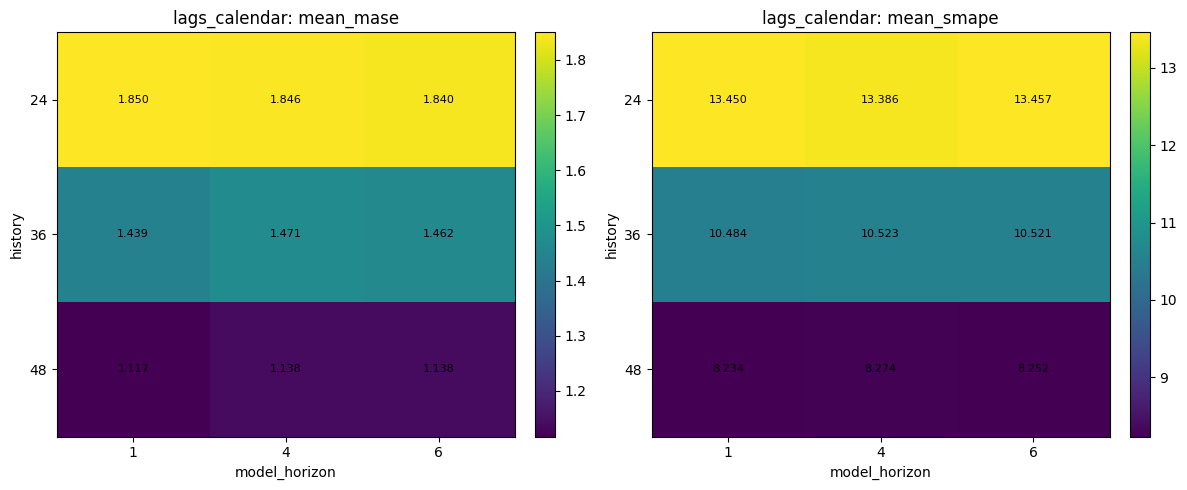

In [66]:
plot_two_heatmaps(
    df=grid_lags_calendar,
    value_col_1="mean_mase",
    value_col_2="mean_smape",
    index_col="history",
    columns_col="model_horizon",
    title_1="lags_calendar: mean_mase",
    title_2="lags_calendar: mean_smape",
)

In [67]:
display(grid_lags_calendar.sort_values("mean_mase").head(3))
display(grid_lags_calendar.sort_values("mean_smape").head(3))

,mean_smape,median_smape,mean_mase,median_mase,n_series,model,config_name,history,model_horizon
6,8.234182,3.900225,1.117268,0.822950,200,lags_calendar,lags_calendar,48,1
8,8.252151,4.070135,1.137702,0.843906,200,lags_calendar,lags_calendar,48,6
7,8.273970,4.314320,1.138348,0.798167,200,lags_calendar,lags_calendar,48,4


,mean_smape,median_smape,mean_mase,median_mase,n_series,model,config_name,history,model_horizon
6,8.234182,3.900225,1.117268,0.822950,200,lags_calendar,lags_calendar,48,1
8,8.252151,4.070135,1.137702,0.843906,200,lags_calendar,lags_calendar,48,6
7,8.273970,4.314320,1.138348,0.798167,200,lags_calendar,lags_calendar,48,4


Для lags_calendar сохраняется тот же общий эффект где  history улучшает качество, а влияние model_horizon остается слабым

спецификация в целом слабее предыдуших двух

### запуск для lags_fourier

In [68]:
grid_lags_fourier, metrics_lags_fourier = run_stage2_for_one_config(
    config_name="lags_fourier",
    train_df=train_df,
    holdout_fit_df=holdout_fit_stage2_df,
    truth_df=truth_df,
    history_grid=stage2_history_grid,
    model_horizon_grid=stage2_model_horizon_grid,
    h=12,
    m=12,
    catboost_params=catboost_params_stage2,
)

display(grid_lags_fourier)

lags_fourier | history=24 | model_horizon=1
lags_fourier | history=24 | model_horizon=4
lags_fourier | history=24 | model_horizon=6
lags_fourier | history=36 | model_horizon=1
lags_fourier | history=36 | model_horizon=4
lags_fourier | history=36 | model_horizon=6
lags_fourier | history=48 | model_horizon=1
lags_fourier | history=48 | model_horizon=4
lags_fourier | history=48 | model_horizon=6


,mean_smape,median_smape,mean_mase,median_mase,n_series,model,config_name,history,model_horizon
0,13.381753,6.726086,1.850857,1.407843,200,lags_fourier,lags_fourier,24,1
1,13.313672,6.710097,1.825049,1.400332,200,lags_fourier,lags_fourier,24,4
2,13.426103,6.703872,1.864234,1.441613,200,lags_fourier,lags_fourier,24,6
3,10.332534,5.161772,1.439497,1.047673,200,lags_fourier,lags_fourier,36,1
4,10.446876,5.098553,1.468664,1.132320,200,lags_fourier,lags_fourier,36,4
5,10.426375,5.134433,1.477760,1.114856,200,lags_fourier,lags_fourier,36,6
6,8.180272,3.916046,1.125473,0.801757,200,lags_fourier,lags_fourier,48,1
7,8.186434,4.064004,1.115546,0.830170,200,lags_fourier,lags_fourier,48,4
8,8.361270,4.170568,1.170423,0.865374,200,lags_fourier,lags_fourier,48,6


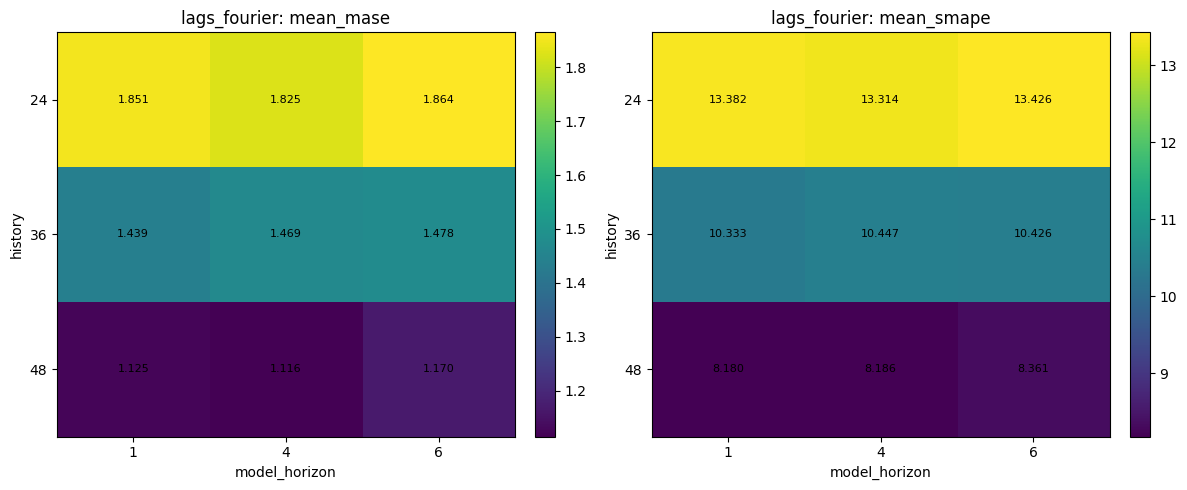

In [69]:
plot_two_heatmaps(
    df=grid_lags_fourier,
    value_col_1="mean_mase",
    value_col_2="mean_smape",
    index_col="history",
    columns_col="model_horizon",
    title_1="lags_fourier: mean_mase",
    title_2="lags_fourier: mean_smape",
)

In [70]:
display(grid_lags_fourier.sort_values("mean_mase").head(3))
display(grid_lags_fourier.sort_values("mean_smape").head(3))

,mean_smape,median_smape,mean_mase,median_mase,n_series,model,config_name,history,model_horizon
7,8.186434,4.064004,1.115546,0.830170,200,lags_fourier,lags_fourier,48,4
6,8.180272,3.916046,1.125473,0.801757,200,lags_fourier,lags_fourier,48,1
8,8.361270,4.170568,1.170423,0.865374,200,lags_fourier,lags_fourier,48,6


,mean_smape,median_smape,mean_mase,median_mase,n_series,model,config_name,history,model_horizon
6,8.180272,3.916046,1.125473,0.801757,200,lags_fourier,lags_fourier,48,1
7,8.186434,4.064004,1.115546,0.830170,200,lags_fourier,lags_fourier,48,4
8,8.361270,4.170568,1.170423,0.865374,200,lags_fourier,lags_fourier,48,6


для lags_fourier общий эффект сохраняется, но в отличие от предыдущих спецификаций здесь  слишком большой прямой прогнозный блок может ухудшать качество

### запуск для lags_seasonal_calendar

In [71]:
grid_lags_seasonal_calendar, metrics_lags_seasonal_calendar = run_stage2_for_one_config(
    config_name="lags_seasonal_calendar",
    train_df=train_df,
    holdout_fit_df=holdout_fit_stage2_df,
    truth_df=truth_df,
    history_grid=stage2_history_grid,
    model_horizon_grid=stage2_model_horizon_grid,
    h=12,
    m=12,
    catboost_params=catboost_params_stage2,
)

display(grid_lags_seasonal_calendar)

lags_seasonal_calendar | history=24 | model_horizon=1
lags_seasonal_calendar | history=24 | model_horizon=4
lags_seasonal_calendar | history=24 | model_horizon=6
lags_seasonal_calendar | history=36 | model_horizon=1
lags_seasonal_calendar | history=36 | model_horizon=4
lags_seasonal_calendar | history=36 | model_horizon=6
lags_seasonal_calendar | history=48 | model_horizon=1
lags_seasonal_calendar | history=48 | model_horizon=4
lags_seasonal_calendar | history=48 | model_horizon=6


,mean_smape,median_smape,mean_mase,median_mase,n_series,model,config_name,history,model_horizon
0,13.532031,7.049993,1.844010,1.422230,200,lags_seasonal_calendar,lags_seasonal_calendar,24,1
1,13.600373,7.030881,1.866491,1.459450,200,lags_seasonal_calendar,lags_seasonal_calendar,24,4
2,13.666049,6.795436,1.883481,1.494287,200,lags_seasonal_calendar,lags_seasonal_calendar,24,6
3,10.703616,5.298965,1.478546,1.114359,200,lags_seasonal_calendar,lags_seasonal_calendar,36,1
4,10.713187,5.325003,1.480462,1.100319,200,lags_seasonal_calendar,lags_seasonal_calendar,36,4
5,10.697087,5.575536,1.481220,1.095974,200,lags_seasonal_calendar,lags_seasonal_calendar,36,6
6,8.274753,4.114160,1.106549,0.825663,200,lags_seasonal_calendar,lags_seasonal_calendar,48,1
7,8.271788,4.004394,1.113083,0.850423,200,lags_seasonal_calendar,lags_seasonal_calendar,48,4
8,8.304311,4.198779,1.104312,0.849092,200,lags_seasonal_calendar,lags_seasonal_calendar,48,6


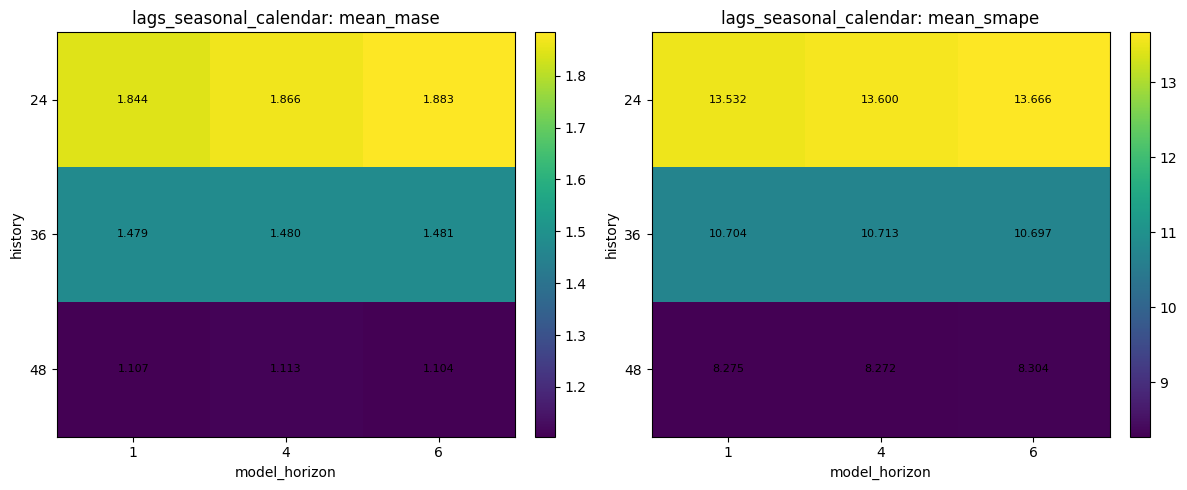

In [72]:
plot_two_heatmaps(
    df=grid_lags_seasonal_calendar,
    value_col_1="mean_mase",
    value_col_2="mean_smape",
    index_col="history",
    columns_col="model_horizon",
    title_1="lags_seasonal_calendar: mean_mase",
    title_2="lags_seasonal_calendar: mean_smape",
)

In [73]:
display(grid_lags_seasonal_calendar.sort_values("mean_mase").head(3))
display(grid_lags_seasonal_calendar.sort_values("mean_smape").head(3))

,mean_smape,median_smape,mean_mase,median_mase,n_series,model,config_name,history,model_horizon
8,8.304311,4.198779,1.104312,0.849092,200,lags_seasonal_calendar,lags_seasonal_calendar,48,6
6,8.274753,4.114160,1.106549,0.825663,200,lags_seasonal_calendar,lags_seasonal_calendar,48,1
7,8.271788,4.004394,1.113083,0.850423,200,lags_seasonal_calendar,lags_seasonal_calendar,48,4


,mean_smape,median_smape,mean_mase,median_mase,n_series,model,config_name,history,model_horizon
7,8.271788,4.004394,1.113083,0.850423,200,lags_seasonal_calendar,lags_seasonal_calendar,48,4
6,8.274753,4.114160,1.106549,0.825663,200,lags_seasonal_calendar,lags_seasonal_calendar,48,1
8,8.304311,4.198779,1.104312,0.849092,200,lags_seasonal_calendar,lags_seasonal_calendar,48,6


вывод похож на lags_seasonal- есть серьезное влияние от длинной истории и почти отстутсвие влияния от horizon

### запуск для lags_seasonal_calendar

In [74]:
grid_lags_seasonal_fourier, metrics_lags_seasonal_fourier = run_stage2_for_one_config(
    config_name="lags_seasonal_fourier",
    train_df=train_df,
    holdout_fit_df=holdout_fit_stage2_df,
    truth_df=truth_df,
    history_grid=stage2_history_grid,
    model_horizon_grid=stage2_model_horizon_grid,
    h=12,
    m=12,
    catboost_params=catboost_params_stage2,
)

display(grid_lags_seasonal_fourier)

lags_seasonal_fourier | history=24 | model_horizon=1
lags_seasonal_fourier | history=24 | model_horizon=4
lags_seasonal_fourier | history=24 | model_horizon=6
lags_seasonal_fourier | history=36 | model_horizon=1
lags_seasonal_fourier | history=36 | model_horizon=4
lags_seasonal_fourier | history=36 | model_horizon=6
lags_seasonal_fourier | history=48 | model_horizon=1
lags_seasonal_fourier | history=48 | model_horizon=4
lags_seasonal_fourier | history=48 | model_horizon=6


,mean_smape,median_smape,mean_mase,median_mase,n_series,model,config_name,history,model_horizon
0,13.533249,7.082065,1.873135,1.459826,200,lags_seasonal_fourier,lags_seasonal_fourier,24,1
1,13.469646,7.121047,1.840191,1.407324,200,lags_seasonal_fourier,lags_seasonal_fourier,24,4
2,13.584080,7.001400,1.865713,1.478858,200,lags_seasonal_fourier,lags_seasonal_fourier,24,6
3,10.763525,5.752193,1.514894,1.119260,200,lags_seasonal_fourier,lags_seasonal_fourier,36,1
4,10.642278,5.456019,1.475568,1.081922,200,lags_seasonal_fourier,lags_seasonal_fourier,36,4
5,10.612598,5.358877,1.457277,1.078170,200,lags_seasonal_fourier,lags_seasonal_fourier,36,6
6,8.257348,4.408634,1.123278,0.836032,200,lags_seasonal_fourier,lags_seasonal_fourier,48,1
7,8.220291,4.090453,1.109118,0.821366,200,lags_seasonal_fourier,lags_seasonal_fourier,48,4
8,8.255754,4.242735,1.101042,0.811595,200,lags_seasonal_fourier,lags_seasonal_fourier,48,6


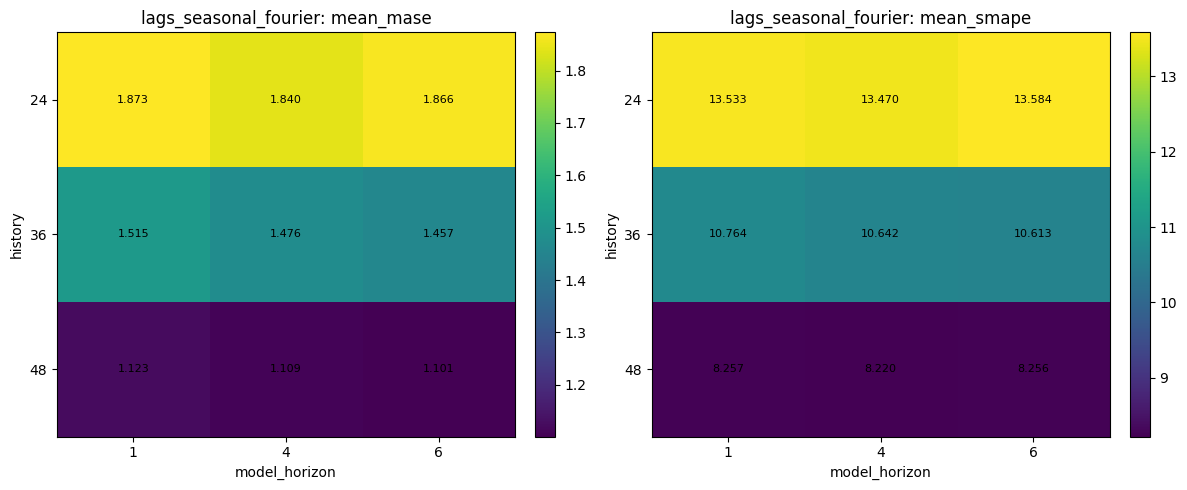

In [75]:
plot_two_heatmaps(
    df=grid_lags_seasonal_fourier,
    value_col_1="mean_mase",
    value_col_2="mean_smape",
    index_col="history",
    columns_col="model_horizon",
    title_1="lags_seasonal_fourier: mean_mase",
    title_2="lags_seasonal_fourier: mean_smape",
)

In [76]:
display(grid_lags_seasonal_fourier.sort_values("mean_mase").head(3))
display(grid_lags_seasonal_fourier.sort_values("mean_smape").head(3))

,mean_smape,median_smape,mean_mase,median_mase,n_series,model,config_name,history,model_horizon
8,8.255754,4.242735,1.101042,0.811595,200,lags_seasonal_fourier,lags_seasonal_fourier,48,6
7,8.220291,4.090453,1.109118,0.821366,200,lags_seasonal_fourier,lags_seasonal_fourier,48,4
6,8.257348,4.408634,1.123278,0.836032,200,lags_seasonal_fourier,lags_seasonal_fourier,48,1


,mean_smape,median_smape,mean_mase,median_mase,n_series,model,config_name,history,model_horizon
7,8.220291,4.090453,1.109118,0.821366,200,lags_seasonal_fourier,lags_seasonal_fourier,48,4
8,8.255754,4.242735,1.101042,0.811595,200,lags_seasonal_fourier,lags_seasonal_fourier,48,6
6,8.257348,4.408634,1.123278,0.836032,200,lags_seasonal_fourier,lags_seasonal_fourier,48,1


Для lags_seasonal_fourier сохраняется сильный эффект длинной истории, но влияние model_horizon уже не такое как до этого с чистыми Fourier-признаками без вспомогательных элементов - лучший результат достигается не при горизонте 1, а при 4–6, в зависимости от выбранной метрики.

### агрегация метрик из запусков

In [77]:
stage2_all_grid = pd.concat(
    [
        grid_lags_only,
        grid_lags_seasonal,
        grid_lags_calendar,
        grid_lags_fourier,
        grid_lags_seasonal_calendar,
        grid_lags_seasonal_fourier,
    ],
    axis=0,
).reset_index(drop=True)

display(stage2_all_grid)

,mean_smape,median_smape,mean_mase,median_mase,n_series,model,config_name,history,model_horizon
0,13.365743,6.383069,1.835379,1.428148,200,lags_only,lags_only,24,1
1,13.357543,6.506907,1.832439,1.421904,200,lags_only,lags_only,24,4
2,13.342696,6.230557,1.833094,1.413763,200,lags_only,lags_only,24,6
3,10.454739,5.183489,1.463458,1.064999,200,lags_only,lags_only,36,1
4,10.448884,5.092275,1.449110,1.036166,200,lags_only,lags_only,36,4
5,10.484368,5.219525,1.460167,1.094653,200,lags_only,lags_only,36,6
6,8.267522,4.293626,1.128975,0.834144,200,lags_only,lags_only,48,1
7,8.290170,4.301818,1.138227,0.849823,200,lags_only,lags_only,48,4
8,8.296557,4.048293,1.131524,0.832317,200,lags_only,lags_only,48,6
9,13.482121,6.691421,1.857020,1.457186,200,lags_seasonal,lags_seasonal,24,1


## Шаг 3 

In [78]:
stage2_all_grid["combo"] = (
    "H=" + stage2_all_grid["history"].astype(str)
    + ", MH=" + stage2_all_grid["model_horizon"].astype(str)
)

display(stage2_all_grid.head())

,mean_smape,median_smape,mean_mase,median_mase,n_series,model,config_name,history,model_horizon,combo
0,13.365743,6.383069,1.835379,1.428148,200,lags_only,lags_only,24,1,"H=24, MH=1"
1,13.357543,6.506907,1.832439,1.421904,200,lags_only,lags_only,24,4,"H=24, MH=4"
2,13.342696,6.230557,1.833094,1.413763,200,lags_only,lags_only,24,6,"H=24, MH=6"
3,10.454739,5.183489,1.463458,1.064999,200,lags_only,lags_only,36,1,"H=36, MH=1"
4,10.448884,5.092275,1.449110,1.036166,200,lags_only,lags_only,36,4,"H=36, MH=4"


In [79]:
def plot_global_heatmap(
    df,
    value_col,
    row_col="config_name",
    col_col="combo",
    title=None,
    cmap="YlGnBu",
    fmt=".3f",
    figsize=(12, 5),
):
    pivot = df.pivot(index=row_col, columns=col_col, values=value_col)

    desired_order = [
        "lags_only",
        "lags_seasonal",
        "lags_calendar",
        "lags_fourier",
        "lags_seasonal_calendar",
        "lags_seasonal_fourier",
    ]
    row_order = [x for x in desired_order if x in pivot.index]
    pivot = pivot.loc[row_order]

    combo_order = []
    for h in sorted(df["history"].unique()):
        for mh in sorted(df["model_horizon"].unique()):
            combo_order.append(f"H={h}, MH={mh}")

    col_order = [x for x in combo_order if x in pivot.columns]
    pivot = pivot[col_order]

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(pivot.values, cmap=cmap, aspect="auto")

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)

    ax.set_title(title if title is not None else value_col)

    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.iloc[i, j]
            ax.text(j, i, format(val, fmt), ha="center", va="center", fontsize=9)

    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

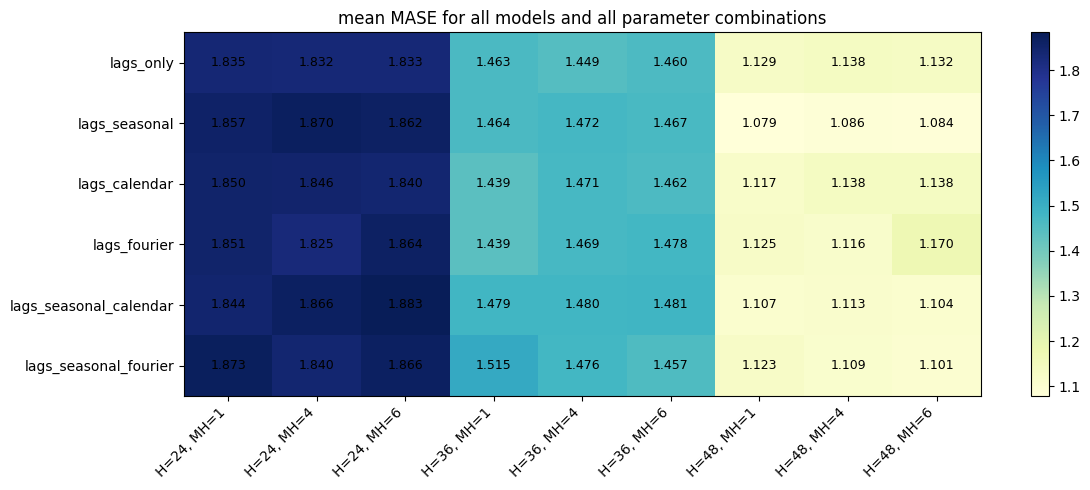

In [81]:
plot_global_heatmap(
    df=stage2_all_grid,
    value_col="mean_mase",
    title="mean MASE for all models and all parameter combinations",
)

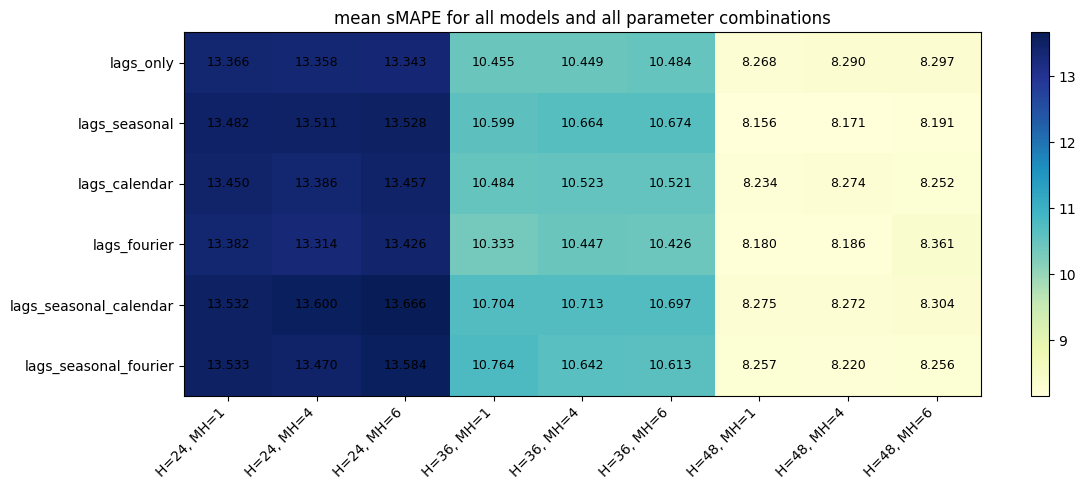

In [82]:
plot_global_heatmap(
    df=stage2_all_grid,
    value_col="mean_smape",
    title="mean sMAPE for all models and all parameter combinations",
)

Если не смотреть на конкретный model_horizon, а в среднем, какой history оказывается лучше?

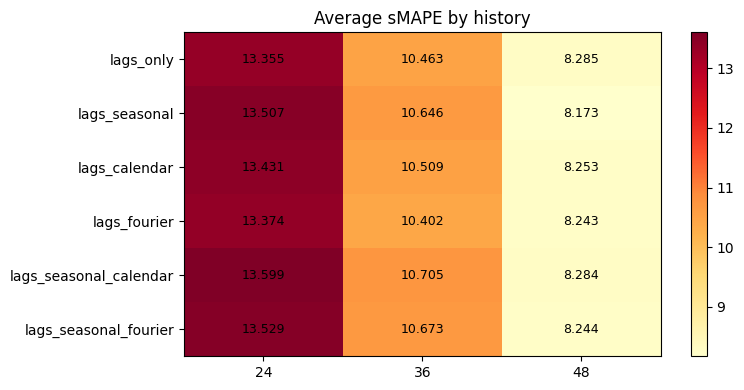

In [83]:
stage2_by_history = (
    stage2_all_grid
    .groupby(["config_name", "history"], as_index=False)
    .agg(
        avg_mase=("mean_mase", "mean"),
        avg_smape=("mean_smape", "mean"),
    )
)
def plot_history_effect_heatmap(
    df,
    value_col,
    title=None,
    cmap="YlOrRd",
    fmt=".3f",
    figsize=(8, 4),
):
    pivot = df.pivot(index="config_name", columns="history", values=value_col)

    desired_order = [
        "lags_only",
        "lags_seasonal",
        "lags_calendar",
        "lags_fourier",
        "lags_seasonal_calendar",
        "lags_seasonal_fourier",
    ]
    row_order = [x for x in desired_order if x in pivot.index]
    pivot = pivot.loc[row_order]

    pivot = pivot[sorted(pivot.columns)]

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(pivot.values, cmap=cmap, aspect="auto")

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)

    ax.set_title(title if title is not None else value_col)

    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.iloc[i, j]
            ax.text(j, i, format(val, fmt), ha="center", va="center", fontsize=9)

    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()
plot_history_effect_heatmap(
    df=stage2_by_history,
    value_col="avg_smape",
    title="Average sMAPE by history",
)

Если не смотреть на конкретный history, а в среднем, какой model_horizon оказывается лучше?

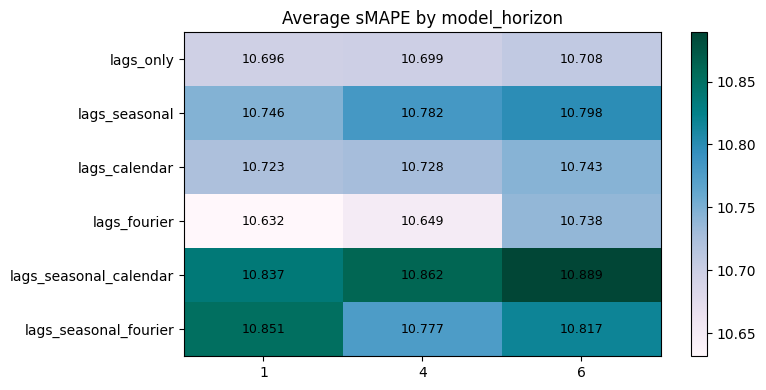

In [85]:
stage2_by_mh = (
    stage2_all_grid
    .groupby(["config_name", "model_horizon"], as_index=False)
    .agg(
        avg_mase=("mean_mase", "mean"),
        avg_smape=("mean_smape", "mean"),
    )
)
def plot_mh_effect_heatmap(
    df,
    value_col,
    title=None,
    cmap="PuBuGn",
    fmt=".3f",
    figsize=(8, 4),
):
    pivot = df.pivot(index="config_name", columns="model_horizon", values=value_col)

    desired_order = [
        "lags_only",
        "lags_seasonal",
        "lags_calendar",
        "lags_fourier",
        "lags_seasonal_calendar",
        "lags_seasonal_fourier",
    ]
    row_order = [x for x in desired_order if x in pivot.index]
    pivot = pivot.loc[row_order]

    pivot = pivot[sorted(pivot.columns)]

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(pivot.values, cmap=cmap, aspect="auto")

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)

    ax.set_title(title if title is not None else value_col)

    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.iloc[i, j]
            ax.text(j, i, format(val, fmt), ha="center", va="center", fontsize=9)

    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()
plot_mh_effect_heatmap(
    df=stage2_by_mh,
    value_col="avg_smape",
    title="Average sMAPE by model_horizon",
)

На третьем этапе результаты свел результаты в общие heatmap по всем спецификациям и комбинациям параметров.

Эти heatmap используются скорее как обобщающая иллюстрация, а основной вывод по устойчивости моделей делается с учетом разборов каждой спецификации по отдельности.

In [96]:
stage3_summary = (
    stage2_all_grid
    .groupby("config_name", as_index=False)
    .agg(
        avg_grid_smape=("mean_smape", "mean"),
        avg_grid_mase=("mean_mase", "mean"),
        best_grid_smape=("mean_smape", "min"),
        best_grid_mase=("mean_mase", "min"),
        worst_grid_smape=("mean_smape", "max"),
        worst_grid_mase=("mean_mase", "max"),
    )
)

stage3_summary["smape_range"] = stage3_summary["worst_grid_smape"] - stage3_summary["best_grid_smape"]
stage3_summary["mase_range"] = stage3_summary["worst_grid_mase"] - stage3_summary["best_grid_mase"]

stage3_summary = stage3_summary.sort_values(
    ["avg_grid_mase", "avg_grid_smape"]
).reset_index(drop=True)


In [97]:
top3_avg_mase = (
    stage3_summary
    .sort_values(["avg_grid_mase", "avg_grid_smape"])
    [["config_name", "avg_grid_mase", "avg_grid_smape", "mase_range", "smape_range"]]
    .head(3)
    .reset_index(drop=True)
)

top3_avg_smape = (
    stage3_summary
    .sort_values(["avg_grid_smape", "avg_grid_mase"])
    [["config_name", "avg_grid_mase", "avg_grid_smape", "mase_range", "smape_range"]]
    .head(3)
    .reset_index(drop=True)
)

print("Top-3 by average MASE over grid")
display(top3_avg_mase)

print("Top-3 by average sMAPE over grid")
display(top3_avg_smape)

Top-3 by average MASE over grid


,config_name,avg_grid_mase,avg_grid_smape,mase_range,smape_range
0,lags_seasonal,1.471226,10.775238,0.791169,5.372076
1,lags_only,1.474708,10.700913,0.706404,5.098221
2,lags_calendar,1.477858,10.731319,0.732548,5.222981


Top-3 by average sMAPE over grid


,config_name,avg_grid_mase,avg_grid_smape,mase_range,smape_range
0,lags_fourier,1.481945,10.672810,0.748688,5.245831
1,lags_only,1.474708,10.700913,0.706404,5.098221
2,lags_calendar,1.477858,10.731319,0.732548,5.222981


In [98]:
top3_best_mase = (
    stage3_summary
    .sort_values(["best_grid_mase", "best_grid_smape"])
    [["config_name", "best_grid_mase", "best_grid_smape", "mase_range", "smape_range"]]
    .head(3)
    .reset_index(drop=True)
)

top3_best_smape = (
    stage3_summary
    .sort_values(["best_grid_smape", "best_grid_mase"])
    [["config_name", "best_grid_mase", "best_grid_smape", "mase_range", "smape_range"]]
    .head(3)
    .reset_index(drop=True)
)

print("Top-3 by best MASE on grid")
display(top3_best_mase)

print("Top-3 by best sMAPE on grid")
display(top3_best_smape)

Top-3 by best MASE on grid


,config_name,best_grid_mase,best_grid_smape,mase_range,smape_range
0,lags_seasonal,1.078867,8.156302,0.791169,5.372076
1,lags_seasonal_fourier,1.101042,8.220291,0.772093,5.363789
2,lags_seasonal_calendar,1.104312,8.271788,0.779169,5.394261


Top-3 by best sMAPE on grid


,config_name,best_grid_mase,best_grid_smape,mase_range,smape_range
0,lags_seasonal,1.078867,8.156302,0.791169,5.372076
1,lags_fourier,1.115546,8.180272,0.748688,5.245831
2,lags_seasonal_fourier,1.101042,8.220291,0.772093,5.363789


In [100]:
best_model_overall_mase = (
    stage2_all_grid
    .sort_values(["mean_mase", "mean_smape"])
    .head(2)
    .reset_index(drop=True)
)

print("Best overall models by MASE")
display(best_model_overall_mase)
best_model_overall_smape = (
    stage2_all_grid
    .sort_values(["mean_smape", "mean_mase"])
    .head(2)
    .reset_index(drop=True)
)

print("Best overall models by sMAPE")
display(best_model_overall_smape)

Best overall models by MASE


,mean_smape,median_smape,mean_mase,median_mase,n_series,model,config_name,history,model_horizon,combo
0,8.156302,3.996021,1.078867,0.783107,200,lags_seasonal,lags_seasonal,48,1,"H=48, MH=1"
1,8.190928,4.029077,1.083757,0.802590,200,lags_seasonal,lags_seasonal,48,6,"H=48, MH=6"


Best overall models by sMAPE


,mean_smape,median_smape,mean_mase,median_mase,n_series,model,config_name,history,model_horizon,combo
0,8.156302,3.996021,1.078867,0.783107,200,lags_seasonal,lags_seasonal,48,1,"H=48, MH=1"
1,8.171228,4.020628,1.085531,0.777961,200,lags_seasonal,lags_seasonal,48,4,"H=48, MH=4"


На третьем этапе наиболее универсальной спецификацией оказалась lags_seasonal. Она показала лучший avg_grid_mase, а также лучшую точку на всей сетке и по MASE, и по sMAPE — history=48, model_horizon=1.

Среди других сильных вариантов выделялись lags_fourier, lags_seasonal_fourier и lags_seasonal_calendar. При этом lags_fourier показал лучший avg_grid_smape, но в среднем по MASE уступил lags_seasonal.

**Итоговый вывод: явное кодирование сезонности полезно, а наиболее универсальной архитектурой в рамках эксперимента выглядит lags_seasonal**

## шаг 4 - сравнение с бейслайнами лучших моделей

In [101]:
best_lags_seasonal_row = (
    grid_lags_seasonal
    .sort_values(["mean_mase", "mean_smape"])
    .head(1)
    .iloc[0]
)
best_lags_seasonal_fourier_row = (
    grid_lags_seasonal_fourier
    .sort_values(["mean_mase", "mean_smape"])
    .head(1)
    .iloc[0]
)
display(best_lags_seasonal_row.to_frame().T)
display(best_lags_seasonal_fourier_row.to_frame().T)

,mean_smape,median_smape,mean_mase,median_mase,n_series,model,config_name,history,model_horizon
6,8.156302,3.996021,1.078867,0.783107,200,lags_seasonal,lags_seasonal,48,1


,mean_smape,median_smape,mean_mase,median_mase,n_series,model,config_name,history,model_horizon
8,8.255754,4.242735,1.101042,0.811595,200,lags_seasonal_fourier,lags_seasonal_fourier,48,6


In [102]:
best_ls_key = (
    int(best_lags_seasonal_row["history"]),
    int(best_lags_seasonal_row["model_horizon"]),
)

best_lsf_key = (
    int(best_lags_seasonal_fourier_row["history"]),
    int(best_lags_seasonal_fourier_row["model_horizon"]),
)

best_ls_pred_df = metrics_lags_seasonal[best_ls_key]["pred_df"]
best_ls_metrics_df = metrics_lags_seasonal[best_ls_key]["metrics_df"]

best_lsf_pred_df = metrics_lags_seasonal_fourier[best_lsf_key]["pred_df"]
best_lsf_metrics_df = metrics_lags_seasonal_fourier[best_lsf_key]["metrics_df"]

display(best_ls_pred_df.head())
display(best_lsf_pred_df.head())

,unique_id,ds,y_pred
0,M10227,2015-01-31,3106.261608
1,M10227,2015-02-28,3215.440969
2,M10227,2015-03-31,3039.044531
3,M10227,2015-04-30,3260.948135
4,M10227,2015-05-31,3075.902442


,unique_id,ds,y_pred
0,M10227,2015-01-31,3093.975499
1,M10227,2015-02-28,3210.343993
2,M10227,2015-03-31,3127.818991
3,M10227,2015-04-30,3628.300911
4,M10227,2015-05-31,2946.359764


In [104]:
final_metrics = {
    "AutoETS": baseline_metrics["AutoETS"],
    "AutoTheta": baseline_metrics["AutoTheta"],
    "lags_seasonal_best": best_ls_metrics_df,
    "lags_seasonal_fourier_best": best_lsf_metrics_df,
}
final_summary = compare_models(final_metrics)
final_wins_mase = count_series_wins(final_metrics, metric="mase")
final_wins_smape = count_series_wins(final_metrics, metric="smape")

display(final_summary)
display(final_wins_mase)
display(final_wins_smape)

,model,mean_smape,median_smape,mean_mase,median_mase,n_series
0,AutoETS,6.458918,3.122006,0.754907,0.621262,200
1,AutoTheta,6.323814,2.936599,0.762348,0.616357,200
2,lags_seasonal_best,8.156302,3.996021,1.078867,0.783107,200
3,lags_seasonal_fourier_best,8.255754,4.242735,1.101042,0.811595,200


,model,n_wins,share_wins
0,AutoETS,75,0.375
1,AutoTheta,70,0.350
2,lags_seasonal_best,29,0.145
3,lags_seasonal_fourier_best,26,0.130


,model,n_wins,share_wins
0,AutoETS,76,0.380
1,AutoTheta,69,0.345
2,lags_seasonal_best,31,0.155
3,lags_seasonal_fourier_best,24,0.120


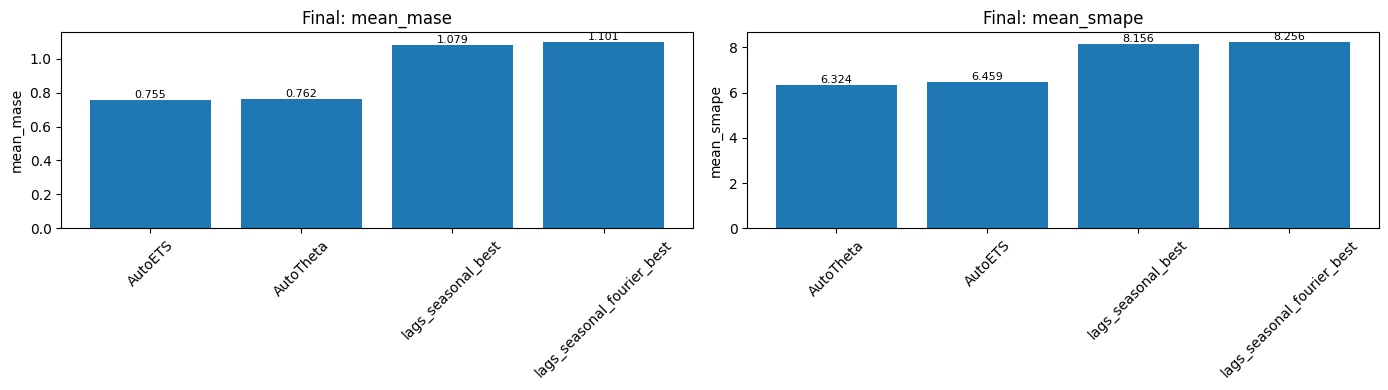

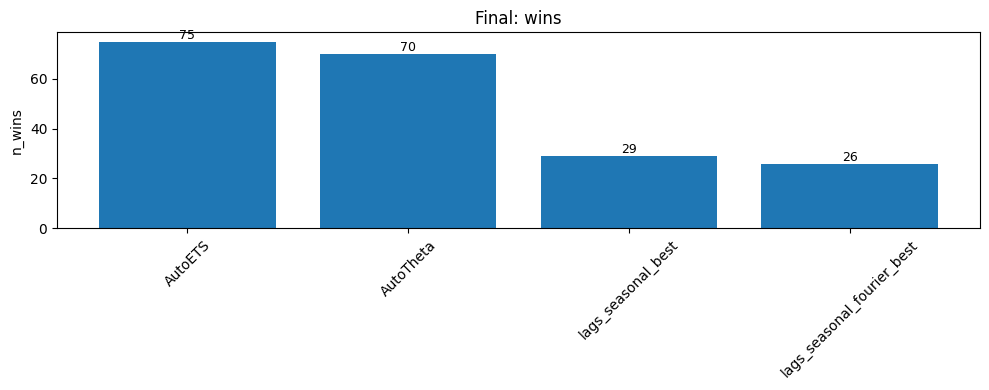

In [105]:
plot_final_comparison(
    summary_df=final_summary,
    wins_df=final_wins_mase,
    model_col="model",
    metric_1="mean_mase",
    metric_2="mean_smape",
)

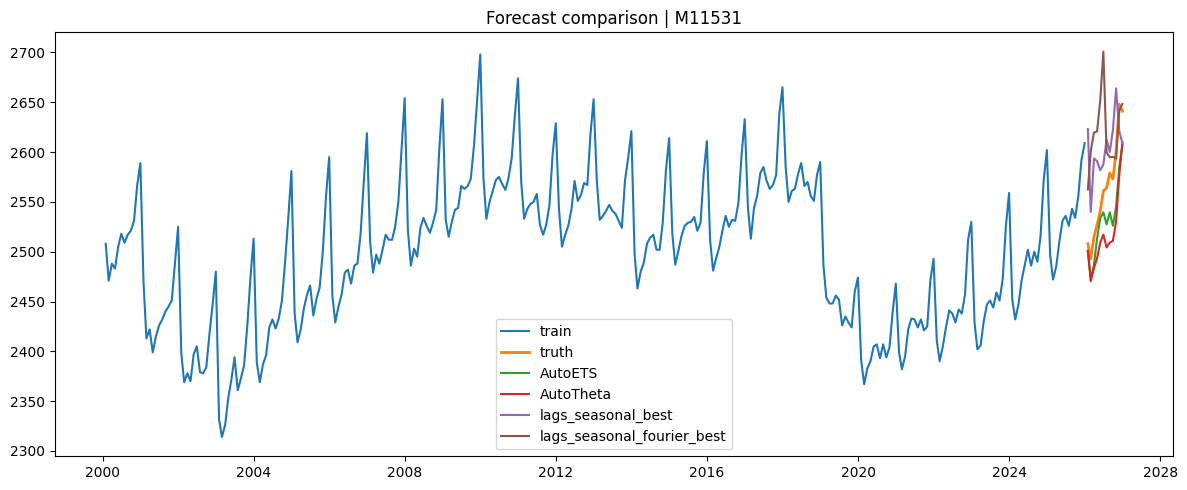

In [107]:
final_pred_dict = {
    "AutoETS": baseline_pred_dict["AutoETS"],
    "AutoTheta": baseline_pred_dict["AutoTheta"],
    "lags_seasonal_best": best_ls_pred_df,
    "lags_seasonal_fourier_best": best_lsf_pred_df,
}

uid_example = random.choice(selected_ids)

plot_forecast_comparison(
    train_df=train_df,
    truth_df=truth_df,
    pred_dict=final_pred_dict,
    uid=uid_example,
)

В финальном сравнении лучшие ML-конфигурации бейзлайны не обошли.

и по средним метрикам, и по числу побед снова лучше выглядели AutoETS и AutoTheta.
Внутри самих ML-моделей картина тоже не поменялась — более надежным вариантом остался lags_seasonal, а добавление Fourier-признаков в среднем не дало выигрыша. 

Ряды у нас monthly и явно сезонные, а на таких данных хорошие статистические бейзлайны часто очень сильны и обыграть их простой глобальной ML-моделью непросто